In [1]:
## Create a vector of the required packages for this analysis
req_packages <- c("ComplexHeatmap", "cowplot", "edgeR", "ggplot2", "ggpubr", "ggrepel", "gridExtra", 
                  "janitor", "multcompView","patchwork", "RColorBrewer", "RUVSeq", "splines", 
                  "stringr", "tidyverse", "vegan", "viridis")

## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

## Characterize genetic variation

### Load in data

In [2]:
# ## load in PCA for whole genome
# eigvec <- read_table2("../workflow/dna/results/plink/plink.eigenvec", col_names = FALSE)
# eigval <- scan("../workflow/dna/results/plink/plink.eigenval")

# ## remove nuisance column
# pca <- eigvec[,-1]

# ## set names
# names(pca)[1] <- "strain"
# names(pca)[2:ncol(pca)] <- paste0("PC", 1:(ncol(pca)-1))

# ## add species information 
# full_pca <- pca %>%
#     separate(strain, into = c("origin", "year", "female"), sep = "_", remove = FALSE)

# write_tsv(full_pca, "intermediate/plink_pca.tsv")

In [3]:
# ## load in PCA for each chromosome
# eigvec_2 <- read_table2("../workflow/dna/results/plink/chromosome_pca/dame_chr2.eigenvec", col_names = FALSE)

# ### reformat PC for joining
# eigvec_2 <- eigvec_2[,-1]
# names(eigvec_2)[1] <- "strain"
# names(eigvec_2)[2:ncol(eigvec_2)] <- paste0("PC", 1:(ncol(eigvec_2)-1))
# eigvec_2 <- eigvec_2 %>%
#     select(strain, PC1, PC2) %>%
#     mutate(chr = "Chromosome 2")

# ## repeat for other chromosomes
# eigvec_3 <- read_table2("../workflow/dna/results/plink/chromosome_pca/dame_chr3.eigenvec", col_names = FALSE)
# eigvec_3 <- eigvec_3[,-1]
# names(eigvec_3)[1] <- "strain"
# names(eigvec_3)[2:ncol(eigvec_3)] <- paste0("PC", 1:(ncol(eigvec_3)-1))
# eigvec_3 <- eigvec_3 %>%
#     select(strain, PC1, PC2) %>%
#     mutate(chr = "Chromosome 3")

# eigvec_4 <- read_table2("../workflow/dna/results/plink/chromosome_pca/dame_chr4.eigenvec", col_names = FALSE)
# eigvec_4 <- eigvec_4[,-1]
# names(eigvec_4)[1] <- "strain"
# names(eigvec_4)[2:ncol(eigvec_4)] <- paste0("PC", 1:(ncol(eigvec_4)-1))
# eigvec_4 <- eigvec_4 %>%
#     select(strain, PC1, PC2) %>%
#     mutate(chr = "Chromosome 4")

# eigvec_5 <- read_table2("../workflow/dna/results/plink/chromosome_pca/dame_chr5.eigenvec", col_names = FALSE)
# eigvec_5 <- eigvec_5[,-1]
# names(eigvec_5)[1] <- "strain"
# names(eigvec_5)[2:ncol(eigvec_5)] <- paste0("PC", 1:(ncol(eigvec_5)-1))
# eigvec_5 <- eigvec_5 %>%
#     select(strain, PC1, PC2) %>%
#     mutate(chr = "Chromosome 5")

# eigvec_x <- read_table2("../workflow/dna/results/plink/chromosome_pca/dame_chrx.eigenvec", col_names = FALSE)
# eigvec_x <- eigvec_x[,-1]
# names(eigvec_x)[1] <- "strain"
# names(eigvec_x)[2:ncol(eigvec_x)] <- paste0("PC", 1:(ncol(eigvec_x)-1))
# eigvec_x <- eigvec_x %>%
#     select(strain, PC1, PC2) %>%
#     mutate(chr = "Chromosome X")

# pca_chr <- rbind(eigvec_2, eigvec_3, eigvec_4, eigvec_5, eigvec_x)

# write_tsv(pca_chr, "intermediate/plink_pca_chr.tsv")

In [4]:
## load in clean data files
pca <- read_tsv("intermediate/plink_pca.tsv")
chr_pca <- read_tsv("intermediate/plink_pca_chr.tsv")

## load in loadings
eigval <- scan("../workflow/dna/results/plink/plink.eigenval")
pve <- data.frame(PC = 1:length(eigval), pve = eigval/sum(eigval)*100)

## load in metadata
metadata <- read_csv("input/YABLab_Drosophila_stocks.csv") %>%
    janitor::clean_names() %>%
    filter(!is.na(latitude)) %>%
    mutate(strain_id = tolower(strain_id),
           strain_id = str_replace_all(strain_id, "\\.", "_")) %>%
    separate_wider_delim(strain_id, delim = "_", names = c("location", "female", "number"), too_few = "align_start", too_many = "drop")
head(metadata)

Rows: 196 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): strain, origin, year, female
dbl (20): PC1, PC2, PC3, PC4, PC5, PC6, PC7, PC8, PC9, PC10, PC11, PC12, PC1...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 918 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): strain, chr
dbl (2): PC1, PC2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 294 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): species_group, Species, strain_ID, strain_type, Genotype, label, s...
dbl  (5): year, latitude, longitude, water_distance_mi, riparian_year

ℹ Use `spec()` to retrieve

species_group,species,location,female,number,strain_type,genotype,label,year,slot,⋯,state,country,latitude,longitude,sequencing,wetland,water_distance_mi,water_source,riparian,riparian_year
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
virilis,D. americana,aa,99,06,wild-type,wt,NA,1999,A5-5,⋯,AR,USA,35.28654,-91.38307,nextera_2020,No,0.08,Riverine,NA,1980
virilis,D. americana,bb,05,10,wild-type,wt,NA,2005,A6-1,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,18,wild-type,wt,NA,2005,A6-2,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,36,wild-type,wt,NA,2005,A6-3,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,red,mutant,red,NA,2005,A6-4,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,44,wild-type,wt,NA,2005,A6-5,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980


### Plot PCAs

In [5]:
pca_meta <- metadata %>%
    mutate(strain = paste(toupper(location), female, number, sep = "_")) %>%
    left_join(pca, by = "strain")

pca_meta_plot <- pca_meta %>%
    ggplot(aes(PC1, PC2, col = latitude)) + 
        geom_point(size = 3, alpha = 0.75) + 
        xlab(paste0("PC1 (", signif(pve$pve[1], 3), "%)")) +
        ylab(paste0("PC2 (", signif(pve$pve[2], 3), "%)")) +
        scale_color_viridis() +
        theme_bw() +
        theme(panel.grid = element_blank())
pca_meta_plot

Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [ ]:
ggsave("figures/coord_plink_pca.png", pca_meta_plot, width = 7, height = 6)

Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [ ]:
cor.test(pca_meta$PC2, pca_meta$latitude)


	Pearson's product-moment correlation

data:  pca_meta$PC2 and pca_meta$latitude
t = -7.9624, df = 130, p-value = 7.353e-13
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.6771757 -0.4452410
sample estimates:
       cor 
-0.5725539 


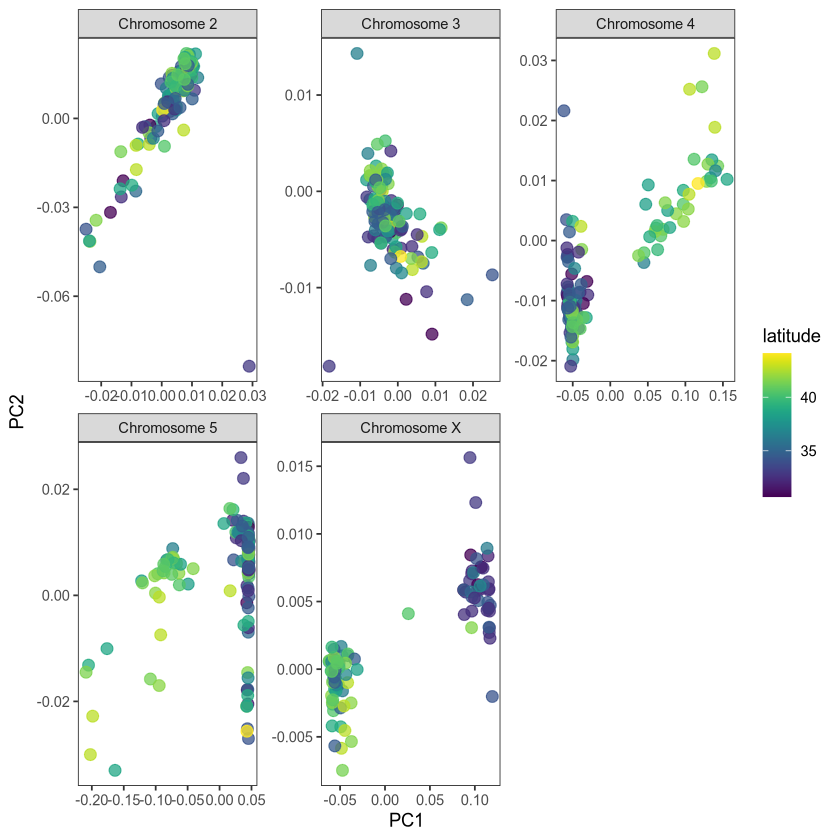

In [ ]:
pca_chr_meta <- metadata %>%
    mutate(strain = paste(toupper(location), female, number, sep = "_")) %>%
    left_join(chr_pca, by = "strain") %>%
    filter(chr != "NA")

pca_chr_plot <-pca_chr_meta %>%
    ggplot(aes(PC1, PC2, col = latitude)) + 
        geom_point(size = 3, alpha = 0.75) + 
        scale_color_viridis() +
        theme_bw() +
        theme(panel.grid = element_blank()) +
        facet_wrap(~chr, scales = "free")
pca_chr_plot

In [ ]:
ggsave("figures/chr_plink_pca.png", pca_chr_plot, width = 9, height = 6)

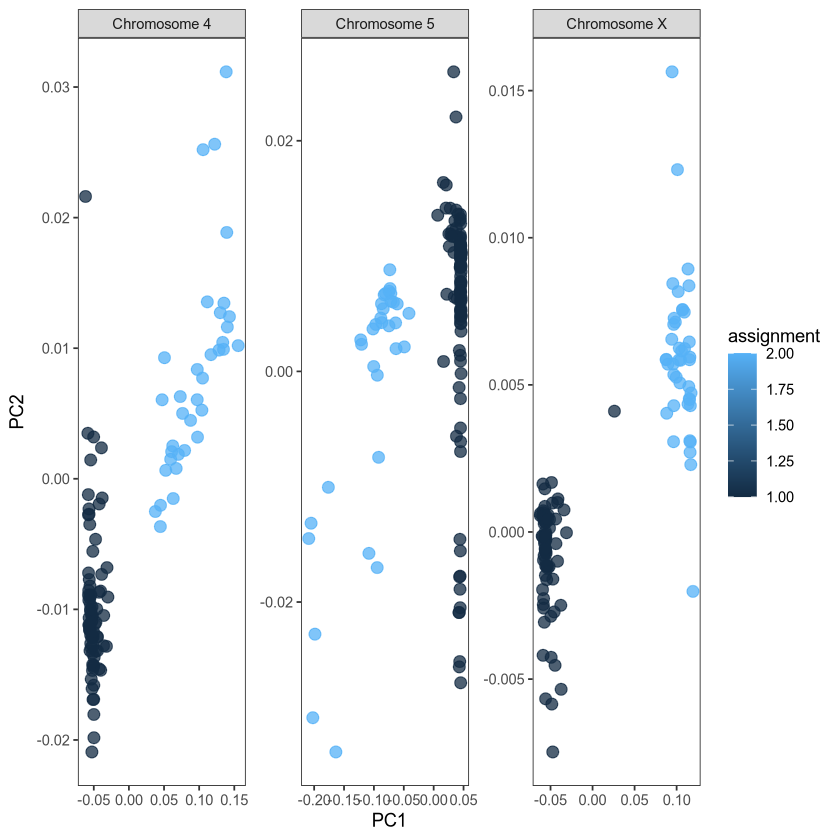

In [ ]:
## get cluster assignments for 2 groups for chromosomes 4, 5, and X
clust_4 <- pca_chr_meta %>%
    filter(chr == "Chromosome 4") %>%
    column_to_rownames("strain") %>%
    select(PC1, PC2) %>%
    as.matrix() %>%
    dist() %>%
    hclust()
cut_4 <- cutree(clust_4, 2)
clust_4 <- cut_4 %>%
    as.data.frame() %>%
    rename(cluster_4 = 1) %>%
    rownames_to_column("strain")

clust_5 <- pca_chr_meta %>%
    filter(chr == "Chromosome 5") %>%
    column_to_rownames("strain") %>%
    select(PC1, PC2) %>%
    as.matrix() %>%
    dist() %>%
    hclust()
cut_5 <- cutree(clust_5, 2)
clust_5 <- cut_5 %>%
    as.data.frame() %>%
    rename(cluster_5 = 1) %>%
    rownames_to_column("strain")


clust_x <- pca_chr_meta %>%
    filter(chr == "Chromosome X") %>%
    column_to_rownames("strain") %>%
    select(PC1, PC2) %>%
    as.matrix() %>%
    dist() %>%
    hclust()
cut_x <- cutree(clust_x, 2)
clust_x <- cut_x %>%
    as.data.frame() %>%
    rename(cluster_x = 1) %>%
    rownames_to_column("strain")

## combine cluster assignments with PCA
clust <- full_join(clust_4, clust_5, by = "strain") %>%
    full_join(clust_x, by = "strain")
pca_clust <- pca_chr_meta %>%
    filter(chr == "Chromosome 4" | chr == "Chromosome 5" | chr == "Chromosome X") %>%
    select(strain, chr, PC1, PC2) %>%
    full_join(clust, by = "strain") %>%
    mutate(assignment = case_when(chr == "Chromosome 4" ~ cluster_4,
                                  chr == "Chromosome 5" ~ cluster_5,
                                  chr == "Chromosome X" ~ cluster_x)) %>%
    select(strain, chr, PC1, PC2, assignment) %>%
    na.omit()

## plot PCA
pca_clust_plot <- pca_clust %>%
    ggplot(aes(x = PC1, y = PC2, color = assignment)) +
        geom_point(size = 3, alpha = 0.75) + 
        theme_bw() +
        theme(panel.grid = element_blank()) +
        facet_wrap(~chr, scales = "free")
pca_clust_plot

In [ ]:
## determine which strains have agreement between the cluster assignments
pca_clust_agreement <- pca_clust %>%
    select(-c(PC1, PC2)) %>%
    mutate(chr = str_replace_all(chr, " ", "_")) %>%
    pivot_wider(names_from = chr, values_from = assignment) %>%
    na.omit() %>%
    mutate(agree = case_when(Chromosome_4 != Chromosome_X & Chromosome_4 == Chromosome_5 ~ "full",
                             Chromosome_4 != Chromosome_X ~ "fusion",
                             Chromosome_4 == Chromosome_5 ~ "autosome",
                             Chromosome_5 != Chromosome_X ~ "other"))

## count how many strains have cluster assignments in common
pca_clust_agreement %>%
    group_by(agree) %>%
    count()

agree,n
<chr>,<int>
autosome,26
full,59
fusion,16
other,13


## Investigate the impact of genetic variants

### Load in data

In [ ]:
# ## load in filtered snpeff results
# snpeff_raw <- read_tsv("input/vg_annotated.snpsift_high.vcf", skip = 519) %>%
#     janitor::clean_names()

# ## separate the results information wider
# snpeff_high <- snpeff_raw %>%
#     # filter(!grepl("intergenic_region", info)) %>%
#     pivot_longer(10:ncol(snpeff_raw), names_to = "strain", values_to = "presence") %>%
#     # separate_wider_delim(info, delim = ";", names = c("depth", "read_transversal", "info")) %>%
#     separate_wider_delim(info, delim = "|", too_many = "merge",
#                          names = c("annotation", "annotation_impact", "gene_name", "gene_id", "feature_type", 
#                                    "feature_id", "transcript_biotype", "rank", "HGVS.c", "HGVS.p", 
#                                    "cDNA.pos_cDNA.length", "CDS.pos_CDS.length", "AA.pos_AA.length", 
#                                    "Distance", "ERRORS_WARNINGS_INFO", "snpeff_extra")) %>%
#     separate_wider_delim(presence, delim = ":", too_many = "merge", 
#                          names = c("genotype", "read_depth", "ref.depth_alt.depth", "genotype_likelihood", 
#                                    "phred", "genotype_probability", "expected_depth", 
#                                    "minimum_site_allele_depth")) %>%
#     separate_longer_delim(annotation_impact, delim = "&")

# write_tsv(snpeff_high, "intermediate/snpeff_high.tsv")

In [ ]:
## load in chromosome bp
chromosome_size <- read_tsv("input/dame_g96.chrom.sizes", col_names = FALSE)
colnames(chromosome_size) <- c("number_chrom", "size_bp")
chromosome_size <- chromosome_size %>%
    filter(grepl("Chr", number_chrom))

## load in high effect SNP information
snpeff_high <- read_tsv("intermediate/snpeff_high.tsv")

## load in the strain list
strain_list <- read_tsv("input/pops_origin.tsv", col_names = FALSE) %>%
    mutate_all(., tolower)
colnames(strain_list) <- c("strain", "location")

head(chromosome_size)
head(strain_list)
head(snpeff_high)

Rows: 6 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 5981004 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): number_chrom, id, ref, alt, filter, annotation, annotation_impact,...
dbl  (3): pos, qual, ERRORS_WARNINGS_INFO

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 412 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


number_chrom,size_bp
<chr>,<dbl>
Chr_2,39200649
Chr_3,27942935
Chr_4,30829601
Chr_5,27587546
Chr_6,1836789
Chr_X,32139017


strain,location
<chr>,<chr>
aa_99_06,aa
aa_99_06,aa
bb_05_10,bb
bb_05_10,bb
bb_05_18,bb
bb_05_18,bb


number_chrom,pos,id,ref,alt,qual,filter,annotation,annotation_impact,gene_name,⋯,format,strain,genotype,read_depth,ref.depth_alt.depth,genotype_likelihood,phred,genotype_probability,expected_depth,minimum_site_allele_depth
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,aa_99_06,0/0,5,"5,0","-1.6658,-2.41599,-12.4051",7,-1.26222,3.39241,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_10,0/0,3,"3,0","-1.15467,-1.58018,-7.57366",4,-1.41736,3.56962,3
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_18,0/0,5,"5,0","-1.35211,-2.27185,-12.261",9,-1.21221,5.01266,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_36,0/0,11,"11,0","-3.88771,-6.0703,-28.0464",21,-1.10516,3.97468,11
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_44,0/0,15,"15,0","-2.1338,-5.78636,-35.7538",36,-1.09883,11.2278,15
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_46,1/0,7,"3,4","-9.19754,-1.71297,-6.9283",52,-1.09862,4.3038,3


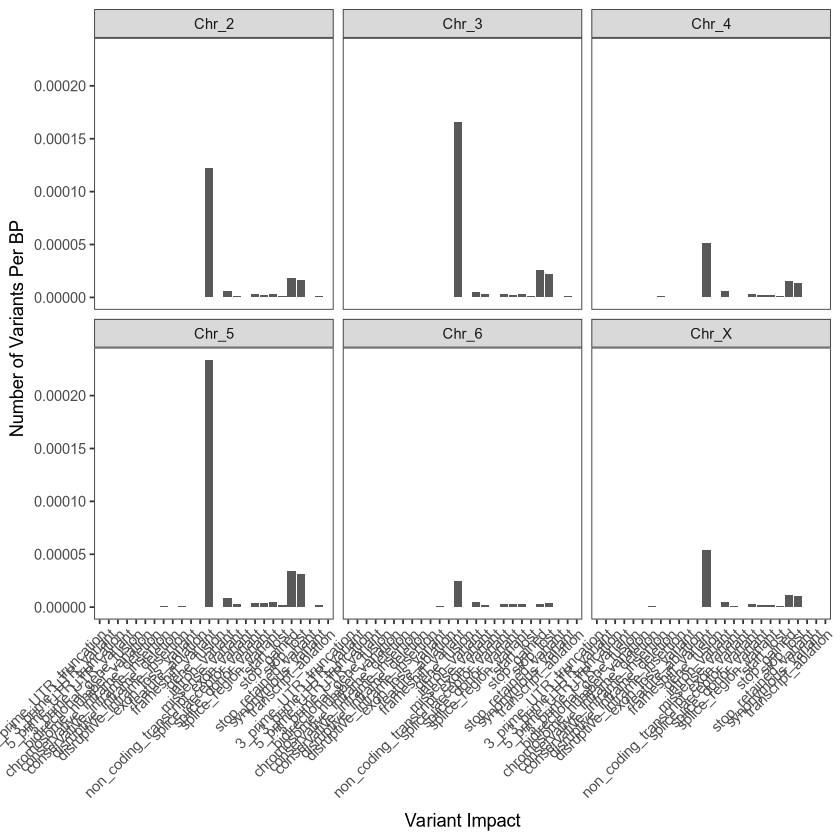

In [ ]:
## plot the number of variants with each impact, per chromosome
impact_chromosome <- snpeff_high %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, annotation_impact) %>%
    unique() %>%
    group_by(number_chrom, annotation_impact) %>%
    count() %>%
    left_join(chromosome_size, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(normal = n/size_bp) %>%
    ggplot(aes(x = annotation_impact, y = normal)) +
        geom_bar(stat = "identity") +
        labs(x = "Variant Impact", y = "Number of Variants Per BP") +
        theme_bw() +
        theme(panel.grid = element_blank(),
              axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
        facet_wrap(~ number_chrom)
impact_chromosome

In [ ]:
ggsave("figures/highimpact_variant_chromosome_bp.png", impact_chromosome, height = 10, width = 15)

### Calculate heterozygosity for high impact alleles

`mutate_all()` ignored the following grouping variables:
• Columns `number_chrom`, `pos`, `alt`, `location`, `genotype`
ℹ Use `mutate_at(df, vars(-group_cols()), myoperation)` to silence the message.
Warning message in left_join(., het_pop, by = "location"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


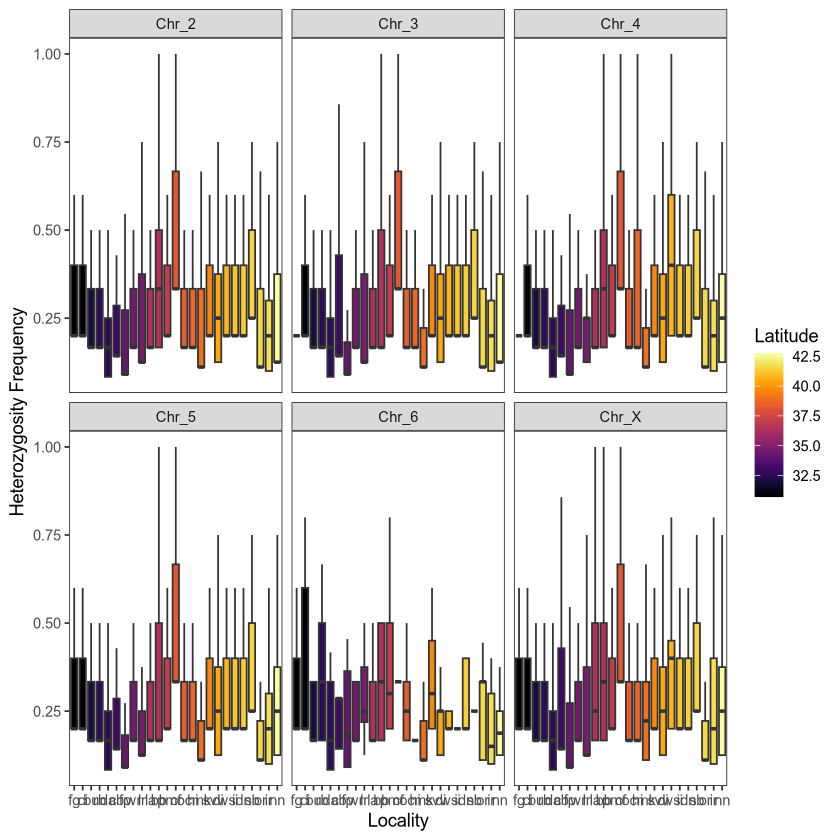

In [ ]:
## count the total number of strains per population 
strain_pop <- snpeff_high %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location) %>%
    count() %>%
    rename(total = n)

## count the number of heterozygotes
het_pop <- snpeff_high %>%
    filter(grepl("Chr", number_chrom) & (genotype == "1/0" | genotype == "0/1")) %>%
    # filter(grepl("stop", annotation_impact)) %>%
    select(number_chrom, pos, alt, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location, genotype) %>%
    count() %>%
    mutate_all(~replace_na(., 0)) %>%
    left_join(strain_pop, by = c("number_chrom", "pos", "alt", "location")) %>%
    mutate(het_freq = n/total)

## plot heterozygosity
het_graph <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location") %>%
    filter(total > 2) %>%
    na.omit() %>%
    ggplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude)) +
    geom_boxplot(outlier.shape = NA) +
    labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
    scale_fill_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank(),
          legend.positino = "bottom") +
    facet_wrap(~number_chrom)

het_graph

In [ ]:
ggsave("figures/heterozygosity_pop.png", het_graph, height = 12, width = 25)

Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


In [ ]:
## create empty data frame to populate
number_chrom <- unique(het_pop$number_chrom)

het_pop_ttest <- matrix(data = NA, nrow = 1, ncol = 3,
                        dimnames = list(c("remove"),
                                        c("number_chrom", "location", "p_value"))) %>%
                as.data.frame()

## calculate how much the heterozygosity frequency deviates from expected for each location per chromosome
for (i in number_chrom) {
    
    ## pull the list of heterozygosity frequencies for the entire chromosome, across populations
    y <-  het_pop %>%
        filter(number_chrom == i) %>%
        pull("het_freq")

    for (j in unique(het_pop$location)) {    
        
        ## pull the heterozygosity frequencies for the location on chromosome
        x <- het_pop %>%
            filter(number_chrom == i & location == j) %>%
            pull("het_freq")
            
        if (length(x) > 2) {        
            ## run the t-test
            test <- t.test(x = x, y = y, alternative = "greater")

            ## populate the data frame
            het_pop_ttest <- het_pop_ttest %>%
                add_row(number_chrom = i, location = j, p_value = test$p.value)

        }
    }
}

## filter out the removed row
het_pop_ttest <- het_pop_ttest %>%
    na.omit()
head(het_pop_ttest)

,number_chrom,location,p_value
,<chr>,<chr>,<dbl>
...2,Chr_2,bb,0.9999924
...3,Chr_2,bu,1.0000000
...4,Chr_2,cb,1.0000000
...5,Chr_2,da,1.0000000
...6,Chr_2,di,1.0000000
...7,Chr_2,fp,1.0000000


Warning message:
“Removed 311801 rows containing missing values or values outside the scale range
(`geom_point()`).”


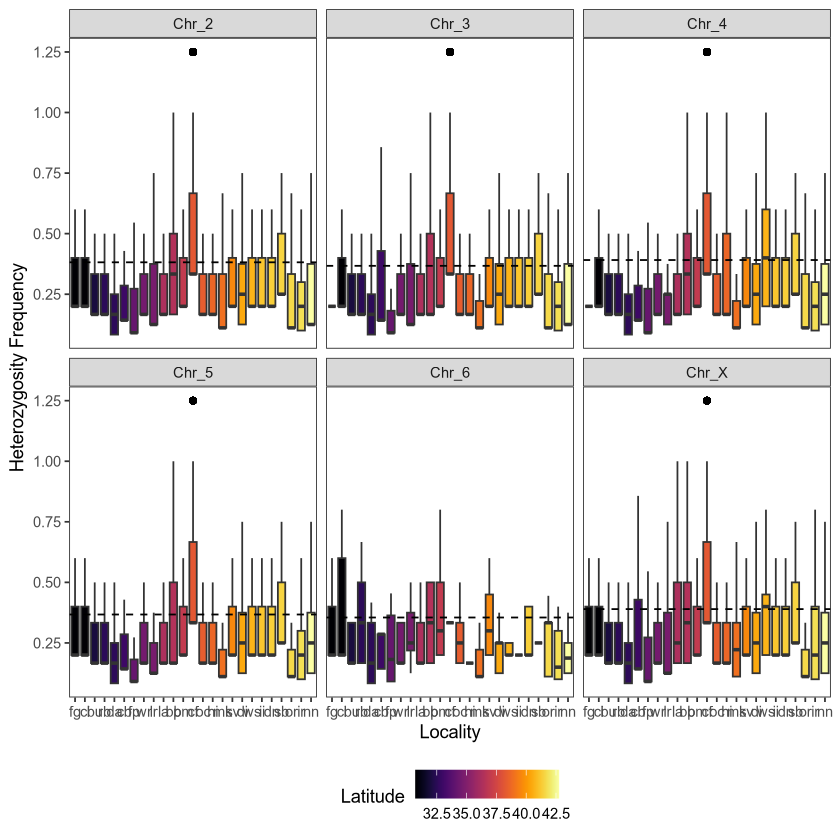

In [ ]:
## calculate the average heterozygosity per chromosome
chrom_het_avg <- het_pop %>%
    group_by(number_chrom) %>%
    summarize(probability = mean(het_freq))

## plot the number of populations that deviate from the chromosomal mean
het_graph_deviate <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location", relationship = "many-to-many") %>%
    filter(total > 2) %>%
    na.omit() %>%
    left_join(het_pop_ttest, by = c("number_chrom", "location"), relationship = "many-to-many") %>%
    left_join(chrom_het_avg, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(deviate = case_when(p_value < 0.05 ~ 1.25,
                               TRUE ~ NA)) %>%
    ggplot() +
        geom_boxplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude), outlier.shape = NA) +
        geom_hline(aes(yintercept = probability), linetype = "dashed") +
        geom_point(aes(x = fct_reorder(location, latitude), y = deviate)) +
        labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
        scale_fill_viridis(option = "B") +
        theme_bw() +
        theme(panel.grid = element_blank(),
            legend.position = "bottom") +
        facet_wrap(~number_chrom)
het_graph_deviate

In [ ]:
ggsave("figures/heterozygosity_pop_deviate.png", het_graph_deviate, height = 6, width = 12)

Warning message:
“Removed 311801 rows containing missing values or values outside the scale range
(`geom_point()`).”


### Determine frequency of deleterious mutations relative to latitude

In [ ]:
# ## load in filtered snpeff results
# snps <- read_tsv("../workflow/dna/results/plink/vg_annotated_pruned.vcf", skip = 55) %>%
#     janitor::clean_names() %>%
#     filter(grepl("Chr_", number_chrom))

# ## separate the results information wider
# snps <- snps %>%
#     pivot_longer(10:ncol(snps), names_to = "strain", values_to = "presence") %>%
#     separate_wider_delim(strain, delim = "_", too_many = "drop", names = c("locality", "female", "number")) %>%
#     mutate(strain = paste(locality, female, number, sep = "_"),
#            strain = toupper(strain)) %>%
#     separate_wider_delim(presence, delim = ":", too_many = "drop", 
#                          names = c("genotype")) %>%
#     select(number_chrom, pos, id, ref, alt, strain, genotype) %>%
#     unique()

# write_tsv(snps, "intermediate/full_snps.tsv")

In [ ]:
## load in fusion data
snps <- read_tsv("intermediate/full_snps.tsv")
fusion <- read_tsv("input/strain_fusion.tsv") %>%
    janitor::clean_names() %>%
    mutate(strain = str_replace_all(strain, "\\.", "_"))

head(fusion)
head(snps)

Rows: 21156135 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): number_chrom, id, ref, alt, strain, genotype
dbl (1): pos

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 23 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Strain, Status

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,status
<chr>,<chr>
BB_05_18,Fused
FG_06_22,Unfused
FP_10_18,Unfused
HI_99_20,Fused
II_07_04,Segregating
IR_04_34,Fused


number_chrom,pos,id,ref,alt,strain,genotype
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,167416,>5552>5557,GA,TG,BB_05_18,1/1
Chr_2,167416,>5552>5557,GA,TG,BB_05_18,0/0
Chr_2,167416,>5552>5557,GA,TG,BU_06_06,1/1
Chr_2,167416,>5552>5557,GA,TG,BU_06_06,0/0
Chr_2,167416,>5552>5557,GA,TG,BU_06_10,0/0
Chr_2,167416,>5552>5557,GA,TG,CB_05_22,1/1


In [ ]:
## get the number of alleles for each SNP for each fusion type by chromosome
chr_fusion_allele_only <- snps %>%
    mutate(genotype = case_when(genotype == "1/1" ~ 2,
                                genotype == "0/1" | genotype == "1/0" ~ 1,
                                genotype == "0/0" ~ 0)) %>%
    inner_join(fusion, by = "strain") %>%
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    mutate_all(replace_na, 0) %>%
    group_by(number_chrom, status) %>%
    reframe(allele = sum(genotype),
            count = n())

## get the number of alleles that are not SNPs for each fusion type by chromosome
chr_fusion_alleles <- chr_fusion_allele_only %>%
    full_join(chromosome_size, by = "number_chrom") %>%
    mutate(chromosome_sites = size_bp*count*2,
           nonallele = chromosome_sites-allele) %>%
    pivot_longer(c(allele, nonallele), names_to = "snp", values_to = "value") %>%
    select(number_chrom, status, chromosome_sites, snp, value)
head(chr_fusion_alleles)

number_chrom,status,chromosome_sites,snp,value
<chr>,<chr>,<dbl>,<chr>,<dbl>
Chr_2,Fused,1.374815e+14,allele,7.455410e+05
Chr_2,Fused,1.374815e+14,nonallele,1.374815e+14
Chr_2,Unfused,5.935261e+13,allele,3.339700e+05
Chr_2,Unfused,5.935261e+13,nonallele,5.935260e+13
Chr_3,Fused,8.048035e+13,allele,6.077370e+05
Chr_3,Fused,8.048035e+13,nonallele,8.048035e+13


In [ ]:
## determine if there is a difference in SNP number by chromosome
### create empty data frame to populate
chr_snp_chisq <- matrix(NA, nrow = length(unique(chr_fusion_alleles$number_chrom)), ncol = 3,
                           dimnames = list(unique(chr_fusion_alleles$number_chrom), c("pvalue", "fused", "unfused"))) %>%
    as.data.frame()

### calculate chi squared for each chromosome
for (i in unique(chr_fusion_alleles$number_chrom)) {

    ## calculate chi squared
    chrn_snp_mx <- chr_fusion_alleles %>%
        filter(number_chrom == i) %>%
        select(status, snp, value) %>%
        unique() %>%
        pivot_wider(names_from = snp, values_from = value) %>%
        column_to_rownames("status") %>%
        as.matrix()
    chrn_snp_chisq <- chrn_snp_mx %>%
        chisq.test()
    
    ## populate data frame with p value
    chr_snp_chisq[[i, "pvalue"]] <- chrn_snp_chisq$p.value
    chr_snp_chisq[[i, "fused"]] <- chrn_snp_mx["Fused",  "allele"]/chrn_snp_mx["Fused",  "nonallele"]
    chr_snp_chisq[[i, "unfused"]] <- chrn_snp_mx["Unfused",  "allele"]/chrn_snp_mx["Unfused",  "nonallele"]

}

chr_snp_chisq

,pvalue,fused,unfused
,<dbl>,<dbl>,<dbl>
Chr_2,2.137545e-70,5.422848e-09,5.626880e-09
Chr_3,1.331921e-49,7.551372e-09,7.813984e-09
Chr_4,1.120268e-89,6.981775e-09,7.274699e-09
Chr_5,2.686484e-69,7.665996e-09,7.970613e-09
Chr_6,1.563044e-02,1.237381e-07,1.281288e-07
Chr_X,7.246573e-74,6.606355e-09,6.855105e-09


In [ ]:
## determine if there is a higher number of SNPs on the fourth chromosome
fourth_snp_mx <- chr_fusion_alleles %>%
    mutate(chr = case_when(number_chrom == "Chr_4" ~ "fourth",
                           TRUE ~ "other")) %>%
    group_by(chr, snp) %>%
    reframe(value = sum(value)) %>%
    select(chr, snp, value) %>%
    unique() %>%
    pivot_wider(names_from = "snp", values_from = "value") %>%
    column_to_rownames("chr") %>%
    as.matrix()
fourth_snp_mx %>%
    chisq.test()
(fourth_snp_mx[, "allele"])/(fourth_snp_mx[, "nonallele"])


	Pearson's Chi-squared test with Yates' continuity correction

data:  .
X-squared = 2169.9, df = 1, p-value < 2.2e-16


fourth        other 
7.070205e-09 6.726739e-09

In [ ]:
## get the number of each high impact allele
chr_fusion_high_only <- snpeff_high %>%
    filter(grepl("Chr_", number_chrom)) %>%
    select(number_chrom, pos, ref, alt, annotation_impact, strain, genotype) %>%
    filter(grepl("missense", annotation_impact) | grepl("nonsense", annotation_impact)) %>%
    mutate(strain = toupper(strain),
           number = case_when(genotype == "0/0" ~ 0,
                              genotype == "0/1" | genotype == "1/0" ~ 1,
                              genotype == "1/1" ~ 2)) %>%
    na.omit() %>%
    inner_join(fusion, by = "strain") %>%
    group_by(number_chrom, annotation_impact, status) %>%
    reframe(high_allele = sum(number))

## get the total number of snps
chr_fusion_high <- chr_fusion_high_only %>%
    inner_join(chr_fusion_alleles, by = c("number_chrom", "status"))
head(chr_fusion_high)

number_chrom,annotation_impact,status,high_allele,chromosome_sites,snp,value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
Chr_2,missense_variant,Fused,431,1.374815e+14,allele,7.455410e+05
Chr_2,missense_variant,Fused,431,1.374815e+14,nonallele,1.374815e+14
Chr_2,missense_variant,Unfused,146,5.935261e+13,allele,3.339700e+05
Chr_2,missense_variant,Unfused,146,5.935261e+13,nonallele,5.935260e+13
Chr_3,missense_variant,Fused,1180,8.048035e+13,allele,6.077370e+05
Chr_3,missense_variant,Fused,1180,8.048035e+13,nonallele,8.048035e+13


In [ ]:
## determine if there is a difference in SNP number by chromosome
### create empty data frame to populate
chr_high_chisq <- matrix(NA, nrow = length(unique(chr_fusion_high$number_chrom)), ncol = 3,
                           dimnames = list(unique(chr_fusion_high$number_chrom), c("pvalue", "fused", "unfused"))) %>%
    as.data.frame()

### calculate chi squared for each chromosome
for (i in unique(chr_fusion_high$number_chrom)) {

    ## calculate chi squared
    chrn_high_mx <- chr_fusion_high %>%
        filter(number_chrom == i & snp == "allele") %>%
        select(status, high_allele, value) %>%
        rename(snp = value) %>%
        unique() %>%
        column_to_rownames("status") %>%
        as.matrix()
    chrn_high_chisq <- chrn_high_mx %>%
        chisq.test()
    
    ## populate data frame with p value
    chr_high_chisq[[i, "pvalue"]] <- chrn_high_chisq$p.value
    chr_high_chisq[[i, "fused"]] <- chrn_high_mx["Fused",  "high_allele"]/chrn_high_mx["Fused",  "snp"]
    chr_high_chisq[[i, "unfused"]] <- chrn_high_mx["Unfused",  "high_allele"]/chrn_high_mx["Unfused",  "snp"]

}

chr_high_chisq

,pvalue,fused,unfused
,<dbl>,<dbl>,<dbl>
Chr_2,3.951768e-03,0.0005781037,0.0004371650
Chr_3,6.416465e-06,0.0019416294,0.0014961123
Chr_4,4.797137e-03,0.0001926088,0.0001155338
Chr_5,9.897965e-03,0.0008773370,0.0007106767
Chr_6,4.099889e-01,0.0039690161,0.0031419594
Chr_X,1.811092e-02,0.0004387323,0.0003395944


In [ ]:
## determine if there is a higher number of SNPs on the fourth chromosome
fourth_high_mx <- chr_fusion_high %>%
    mutate(chr = case_when(number_chrom == "Chr_4" ~ "fourth",
                           TRUE ~ "other")) %>%
    select(number_chrom, chr, high_allele, value) %>%
    unique() %>%
    group_by(chr) %>%
    reframe(high_allele = sum(high_allele),
            value = sum(value)) %>%
    select(chr, high_allele, value) %>%
    unique() %>%
    column_to_rownames("chr") %>%
    as.matrix()
fourth_high_mx %>%
    chisq.test()
(fourth_high_mx[, "high_allele"])/(fourth_high_mx[, "value"])


	Pearson's Chi-squared test with Yates' continuity correction

data:  .
X-squared = 1089.3, df = 1, p-value < 2.2e-16


fourth        other 
2.385034e-12 1.156571e-11

In [ ]:
## determine if there is a difference in SNP number by chromosome
### create empty data frame to populate
chr_snp_chisq <- matrix(NA, nrow = length(unique(chr_fusion_alleles$number_chrom)), ncol = 3,
                           dimnames = list(unique(chr_fusion_alleles$number_chrom), c("pvalue", "fused", "unfused"))) %>%
    as.data.frame()

### calculate chi squared for each chromosome
for (i in unique(chr_fusion_alleles$number_chrom)) {

    ## calculate chi squared
    chrn_snp_mx <- chr_fusion_alleles %>%
        filter(number_chrom == i) %>%
        select(status, snp, value) %>%
        unique() %>%
        pivot_wider(names_from = snp, values_from = value) %>%
        column_to_rownames("status") %>%
        as.matrix()
    chrn_snp_chisq <- chrn_snp_mx %>%
        chisq.test()
    
    ## populate data frame with p value
    chr_snp_chisq[[i, "pvalue"]] <- chrn_snp_chisq$p.value
    chr_snp_chisq[[i, "fused"]] <- chrn_snp_mx["Fused",  "allele"]/chrn_snp_mx["Fused",  "nonallele"]
    chr_snp_chisq[[i, "unfused"]] <- chrn_snp_mx["Unfused",  "allele"]/chrn_snp_mx["Unfused",  "nonallele"]

}

chr_snp_chisq

## Characterize gene expression variation

#### Characterize multigenome alignment

In [ ]:
## load in alignment summary file
alignment_raw <- read_tsv("../workflow/rna/multigenome/results/multigenome_alignment.tsv")

## separate out file name into strain and genome name
alignment <- alignment_raw %>%
    separate_wider_delim(sample, delim = "_", names = c("hisat2", "locality", "female", "number", "replicate", "genome"), too_few = "align_start", cols_remove = FALSE) %>% 
    select(-hisat2) %>%
    mutate(genome = case_when(is.na(genome) ~ replicate,
                              TRUE ~ genome),
           replicate = case_when(replicate == genome ~ number,
                                 TRUE ~ replicate),
           number = case_when(number == replicate ~ "0",
                              TRUE ~ number),
           strain = paste(locality, female, number, sep = "_")) %>%
    relocate(strain, 1)
head(alignment)

Rows: 303 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): sample
dbl (1): percent_aligned

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,locality,female,number,replicate,genome,sample,percent_aligned
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
BB_05_18,BB,05,18,rep1,G96,hisat2_BB_05_18_rep1_G96,87.75
BB_05_18,BB,05,18,rep1,ML.97.05,hisat2_BB_05_18_rep1_ML.97.05,91.80
BB_05_18,BB,05,18,rep1,SB.02.06,hisat2_BB_05_18_rep1_SB.02.06,92.13
BB_05_18,BB,05,18,rep2,G96,hisat2_BB_05_18_rep2_G96,90.86
BB_05_18,BB,05,18,rep2,ML.97.05,hisat2_BB_05_18_rep2_ML.97.05,94.48
BB_05_18,BB,05,18,rep2,SB.02.06,hisat2_BB_05_18_rep2_SB.02.06,94.67


In [ ]:
## determine if there is overall a better mapping to a single genome
align_anova <- aov(percent_aligned ~ genome + locality, data = alignment)
summary(align_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
genome        2    939   469.4   91.13 <2e-16 ***
locality     29  47047  1622.3  314.98 <2e-16 ***
Residuals   269   1386     5.2                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [ ]:
## determine which genome comparison is driving this difference
align_tukey <- TukeyHSD(align_anova)

## group the chromosomes based on Tukey test
align_groups <- multcompLetters4(align_anova, align_tukey)
alignment_groups <- as.data.frame.list(align_groups$genome) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("genome") %>%
    full_join(alignment, by = "genome")

align_tukey$genome

,diff,lwr,upr,p adj
ML.97.05-G96,3.4589029,2.7024526,4.215353,3.158585e-13
SB.02.06-G96,3.9650495,3.2123909,4.717708,2.949863e-13
SB.02.06-ML.97.05,0.5061466,-0.2503037,1.262597,2.573910e-01


Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


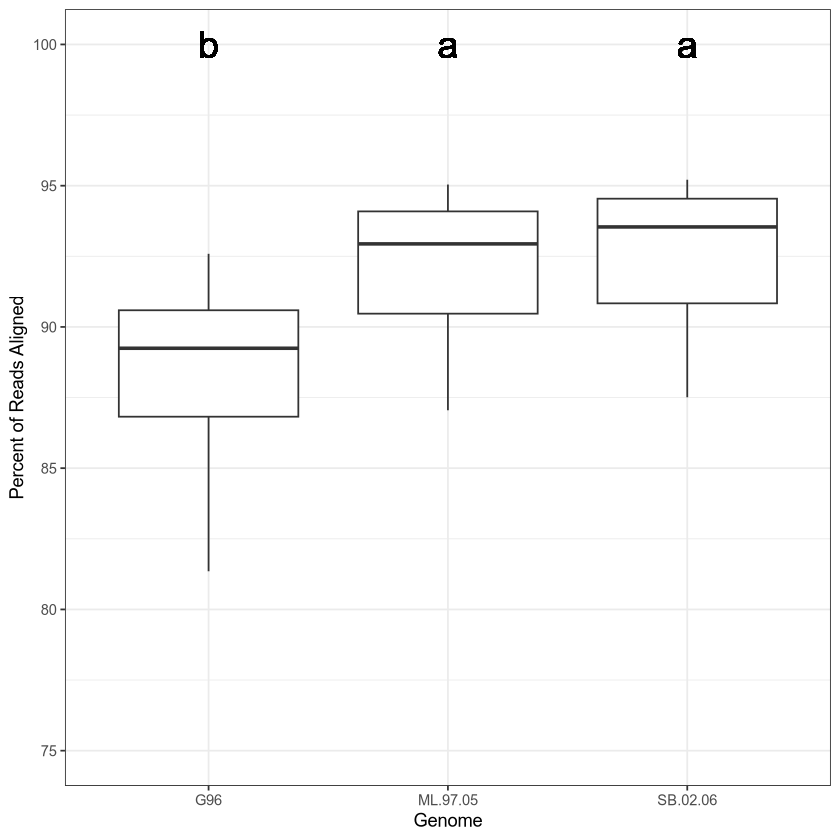

In [ ]:
## plot alignment for each strain
alignment_box <- alignment_groups %>%
    ggplot(aes(x = genome, y = percent_aligned)) +
        geom_boxplot(outlier.shape = NA) +
        geom_text(aes(label = group, y = 100), size = 8) +
        labs(x = "Genome", y = "Percent of Reads Aligned") +
        ylim(75, 100) +
        theme_bw()
alignment_box

In [ ]:
## save figure
ggsave("figures/sb_alignment/multigenome_alignment_boxplot.png", alignment_box)

Saving 7 x 7 in image
Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


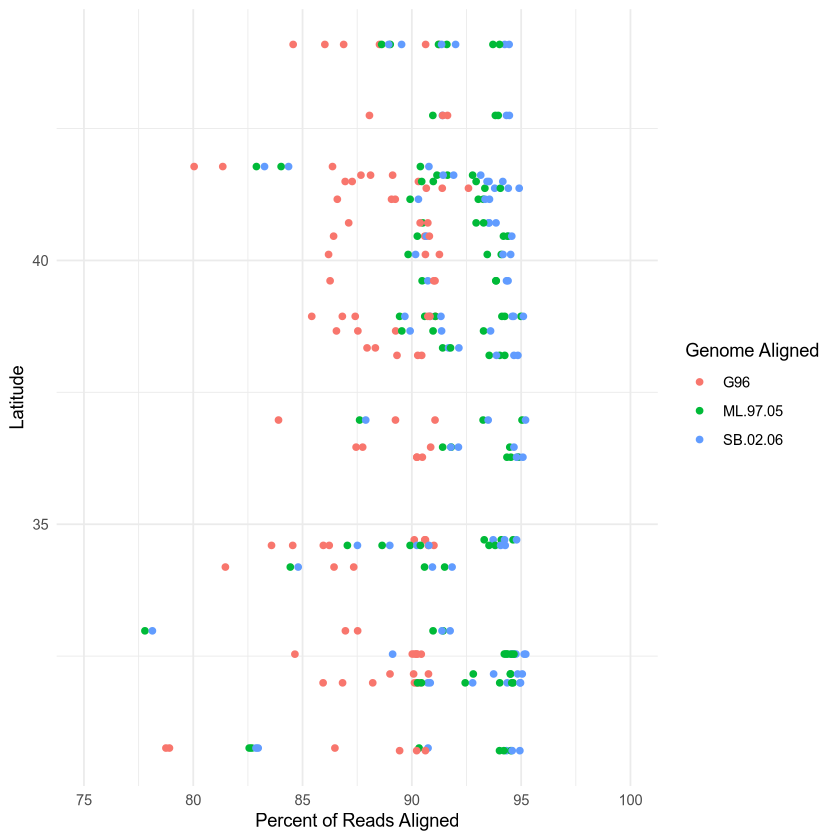

In [ ]:
## get latitude for each population
local_lat <- metadata %>%
    mutate(locality = toupper(location)) %>%
    select(locality, latitude) %>%
    filter(locality %in% alignment$locality) %>%
    select(locality, latitude) %>%
    na.omit() %>%
    unique()

## combine files
lat_alignment <- alignment %>%
    left_join(local_lat, by = "locality")

lat_plot <- lat_alignment %>%
    na.omit() %>%
    ggplot(aes(x = percent_aligned, y = latitude, color = genome)) +
        geom_point() +
        xlim(75, 100) +
        labs(x = "Percent of Reads Aligned", y = "Latitude", color = "Genome Aligned") +
        theme_minimal()
lat_plot

In [ ]:
## save figure
ggsave("figures/sb_alignment/multigenome_alignment_latitude.png", lat_plot)

Saving 7 x 7 in image


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


In [ ]:
## determine if there is a significant correlation between latitude and genome
df_g96 <- lat_alignment %>%
    filter(genome == "G96")
cor.test(df_g96$latitude, df_g96$percent_aligned)

df_sb <- lat_alignment %>%
    filter(genome == "SB.02.06")
cor.test(df_sb$latitude, df_sb$percent_aligned)

df_ml <- lat_alignment %>%
    filter(genome == "ML.97.05")
cor.test(df_ml$latitude, df_ml$percent_aligned)


	Pearson's product-moment correlation

data:  df_g96$latitude and df_g96$percent_aligned
t = 1.2794, df = 93, p-value = 0.2039
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.07193273  0.32445973
sample estimates:
     cor 
0.131517 



	Pearson's product-moment correlation

data:  df_sb$latitude and df_sb$percent_aligned
t = 0.55185, df = 93, p-value = 0.5824
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1460947  0.2557290
sample estimates:
       cor 
0.05713049 



	Pearson's product-moment correlation

data:  df_ml$latitude and df_ml$percent_aligned
t = 0.098423, df = 91, p-value = 0.9218
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1937986  0.2135764
sample estimates:
       cor 
0.01031696 


In [ ]:
## find the genome with the highest alignment for each sample
max_align <- alignment %>%
    select(strain, replicate, genome, percent_aligned) %>%
    mutate(sample = paste(strain, replicate, sep = "_")) %>%
    group_by(sample) %>%
    summarize(genome = genome[which.max(percent_aligned)])

In [ ]:
unique(max_align$genome)

[1] "SB.02.06"

### Load in data

In [ ]:
## load in gene expression data frames
counts_sb <- read_tsv("../workflow/rna/multigenome/results/abundances/SB.02.06/stringtie_gene_matrix.txt")
names_sb <- colnames(counts_sb) %>%
    as.data.frame()
colnames(names_sb) <- "name"

samples_sb <- names_sb %>%
    mutate(name = str_remove_all(name, "/home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/HISAT-2/SB.02.06/"),
           name = str_remove_all(name, ".csorted.hisat2.bam")) %>%
    filter(grepl("SB", name)) %>%
    mutate(name = str_remove_all(name, "_SB.02.06")) %>%
    pull("name")
colnames_sb <- c("gene", samples_sb)
colnames(counts_sb) <- colnames_sb

raw_counts <- counts_sb %>%
    column_to_rownames("gene")

Rows: 14748 Columns: 102
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (1): Geneid
dbl (101): /home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/H...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
## load in GTF
gtf_raw <- read_tsv("/home/yahmed-labshare/data/genomes/virilis_group/americana/SB.02.06/Muller/Polished/gffcompare/sb.02.06.combined.gtf", col_names = FALSE)

## clean up GTF for downstream use
colnames(gtf_raw) <- c("chromosome", "source", "feature", "start", "end", "score", "strand", "frame", "attribute")
gtf <- gtf_raw %>%
    filter(feature == "transcript") %>%
    mutate(attribute = str_remove_all(attribute, "\""),
           attribute = str_remove_all(attribute, " "),
           chromosome = str_remove_all(chromosome, "_RagTag")) %>%
    separate_wider_delim(attribute, delim = ";", names = c("transcript", "gene_id", "gene", "extra"), too_many = "drop") %>%
    mutate(transcript = str_remove_all(transcript, "transcript_id"),
           gene_id = str_remove_all(gene_id, "gene_id"),
           gene = str_remove_all(gene, "oId"),
           gene = str_remove_all(gene, "gene_name"),
           extra = str_remove_all(chromosome, "tss_id"))

## filter for only genes and their chromosome
gtf_genes <- gtf %>%
    filter(feature == "transcript" & grepl("Chr", chromosome)) %>%
    select(chromosome, gene) %>%
    unique()
head(gtf_genes)

Rows: 283442 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): X1, X2, X3, X6, X7, X8, X9
dbl (2): X4, X5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


chromosome,gene
<chr>,<chr>
Chr_2,g1.t1
Chr_2,g2.t1
Chr_2,g3.t1
Chr_2,g4.t1
Chr_2,g5.t1
Chr_2,g6.t1


### Normalize coutns into reads

In [ ]:
## convert to counts per million and remove reads with fewer than 5 reads per 3 samples
cpm_cm <- cpm(raw_counts)
thresh_cm <- cpm_cm > 5
keep_cm <- rowSums(thresh_cm) >= 3
reads <- raw_counts[keep_cm,]

head(reads)

,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,CB_05_22_rep1,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,16402,9827,7866,16153,6773,7140,5824,6780,7562,12893,⋯,7083,10785,5203,5899,8669,9854,5380,8793,8566,9123
mRpL55,230,379,270,353,306,352,227,507,276,442,⋯,281,335,299,191,376,727,264,452,486,419
ATPsynD,3382,3727,2784,4346,3933,2657,3887,3513,1892,5427,⋯,3623,4833,3165,2267,3243,4950,2318,5353,3990,4339
sav,1991,1749,995,1656,956,728,845,973,871,1926,⋯,1024,1501,808,537,1212,1170,523,1906,1360,1378
Ctns,500,561,516,549,848,371,801,578,625,754,⋯,322,463,370,431,524,277,194,475,801,685
p53,367,423,219,584,498,280,464,364,384,511,⋯,244,373,270,285,440,396,304,375,474,399


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.005531 0.025274 0.044817 0.146252 0.105628 8.835269 

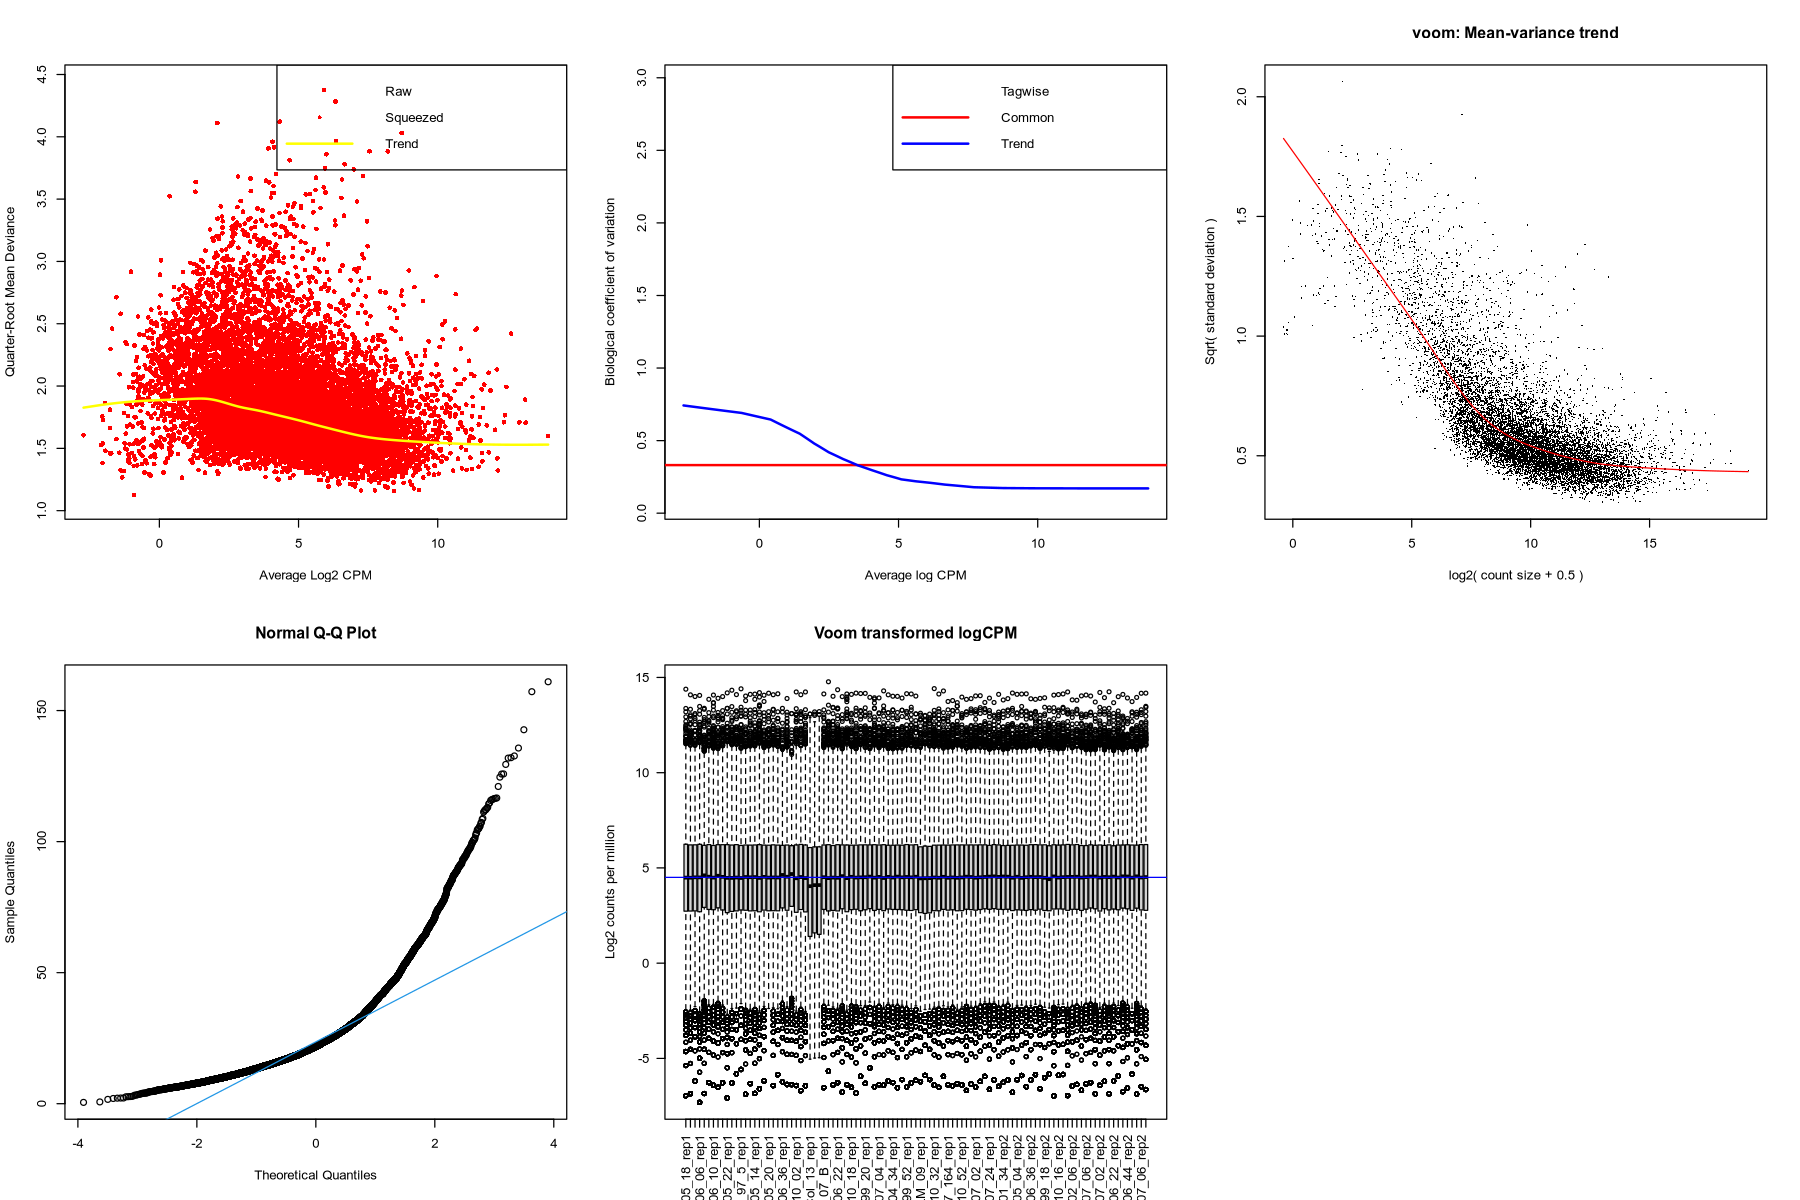

In [ ]:
## create sample information data frame
reads_names <- colnames(reads) %>%
    as.data.frame()
colnames(reads_names) <- "sample"

sample_info <- reads_names %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(strain = case_when(is.na(replicate) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_")),
           replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate))

## create design matrix 
groups <- sample_info$strain
design <- model.matrix(~0 + groups)
rownames(design) <- colnames(reads)
colnames(design) <- str_replace(colnames(design), "groups", "")

## get number of covariables (number of strains)
covariant <- length(unique(sample_info$strain))

## create DGE object
set <- newSeqExpressionSet(as.matrix(reads), phenoData = data.frame(groups, row.names = colnames(reads)))
set <- betweenLaneNormalization(set, which="upper")

y <- DGEList(counts=counts(set), group=groups)
y <- calcNormFactors(y, method="upperquartile")
y <- estimateDisp(y, design, robust = T)
fit <- glmQLFit(y, design, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)

## create new design matrix with RUVr coefficients
design_2 <- model.matrix(~ 0 + groups, data = pData(batch_ruv_res))
colnames(design_2) <- gsub("groups", "", colnames(design_2))

## create DGElist object with new design
dgeList <- DGEList(counts = reads, group = groups)
dgeList <- calcNormFactors(dgeList)
dgeList <- estimateDisp(dgeList, design_2)
dgeList_fit <- glmQLFit(dgeList, design_2, robust = TRUE)
summary(dgeList$tagwise.dispersion)


options(repr.plot.width = 15, repr.plot.height = 10)

# Use the function before each plot
par(mfrow = c(2, 3))

## QL dispersion plot
plotQLDisp(dgeList_fit, col.raw = "white", cex = 0.8, col.trend = "yellow", )

## Biological coefficient of variation
plotBCV(dgeList, col.tagwise = "white", cex = 0.8)

## Mean-variance trend
voom <- voom(dgeList, design_2, plot = TRUE)

## Goodness of fit/Q-Q plot
g.v <- gof(dgeList_fit, plot = FALSE, pcutoff = 0.05, adjust = "holm")
z.v <- zscoreGamma(g.v$gof.statistics,shape=g.v$df/2,scale=2)
qqnorm(z.v); qqline(z.v, col = 4,lwd=1,lty=1)

## normalized CPM check
boxplot(voom$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
abline(h=median(voom$E),col="blue")

In [ ]:
## normalize with new design
y <- estimateDisp(y, design_2, robust = T)
fit <- glmQLFit(y, design_2, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)
RUVrNormalizedCounts <- normCounts(object = batch_ruv_res)
rownames(RUVrNormalizedCounts) <- rownames(reads)

## reformat normalized reads for saving
normalized_reads <- RUVrNormalizedCounts %>%
    as.data.frame() %>%
    rownames_to_column("gene")
head(normalized_reads)

,gene,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,cdi,8583,8785,8738,6625,6595,6659,6446,6552,6328,⋯,7384,7539,7085,7024,7990,7339,7546,7000,7394,7385
2,mRpL55,214,228,256,254,222,261,285,311,336,⋯,306,276,294,267,405,427,405,354,346,381
3,ATPsynD,2488,2542,2837,2759,2516,2599,3015,2770,2933,⋯,3673,3335,3295,3564,3137,3587,3170,3656,3471,3797
4,sav,1203,1218,1218,775,741,772,839,806,971,⋯,1023,887,924,895,870,898,926,1261,1240,1205
5,Ctns,414,400,448,417,427,387,688,679,602,⋯,308,450,395,447,278,347,293,503,568,469
6,p53,265,251,266,324,311,313,393,389,397,⋯,243,362,277,310,385,336,391,325,366,306


In [ ]:
write_tsv(normalized_reads, "intermediate/sb_dagrp_normalized_reads.tsv")

In [ ]:
## pick the top 50% most variable genes
variance_cutoff <- 0.5
variance_per_genes <- apply(RUVrNormalizedCounts, 1, mad)
min_variance <- quantile(variance_per_genes, c(variance_cutoff))
variance_filtered_data <- RUVrNormalizedCounts[variance_per_genes > min_variance, ]

In [ ]:
## Plot sample correlation
data <- log2(variance_filtered_data + 1)
data <- as.matrix(data)
sample_cor <- cor(data, method = "pearson", use = "pairwise.complete.obs")

sampleColLabeling <- sample_info
rownames(sampleColLabeling) <- sampleColLabeling$sample
sampleColLabeling <- subset(sampleColLabeling, select = c("sample", "strain"))

# Prepare the annotations
annotations <- HeatmapAnnotation(
    df = sampleColLabeling
)

## create heat map and save to results

png("figures/sb_reads_heatmap.png", width = 20, height = 14, units = "in", res = 1200)

draw(Heatmap(sample_cor, 
              name = "Correlation", # Name of the heatmap, appears as the title
              show_row_names = TRUE,
              show_column_names = TRUE,
              top_annotation = annotations,
            #    = annotations,  # Assuming you want row annotations as well
              # column_title = "Sample Title", # Title for the columns
              # row_title = "Row Title", # Title for the rows
              column_title_gp = gpar(col = "white"), # Column title text properties
              column_dend_gp = gpar(col = "white"),
              row_dend_gp = gpar(col = "white"),
              row_title_gp = gpar(col = "white"), # Row title text properties
              column_names_gp = gpar(col = "white", fontface = "bold"), # Column label text properties
              row_names_gp = gpar(col = "white", fontface = "bold"), # Row label text properties
              heatmap_legend_param = list(title = "Correlation",
                                    title_gp = gpar(col = "white"),
                                    labels_gp = gpar(col = "white")), # Legend text properties
              # col = viridis(n = 100, option = "inferno")  # Using the 'inferno' color scale from viridis
             ),
    background = "#1E1E1E")

dev.off()

Warning message:
“Setting row names on a tibble is deprecated.”


pdf 
  2

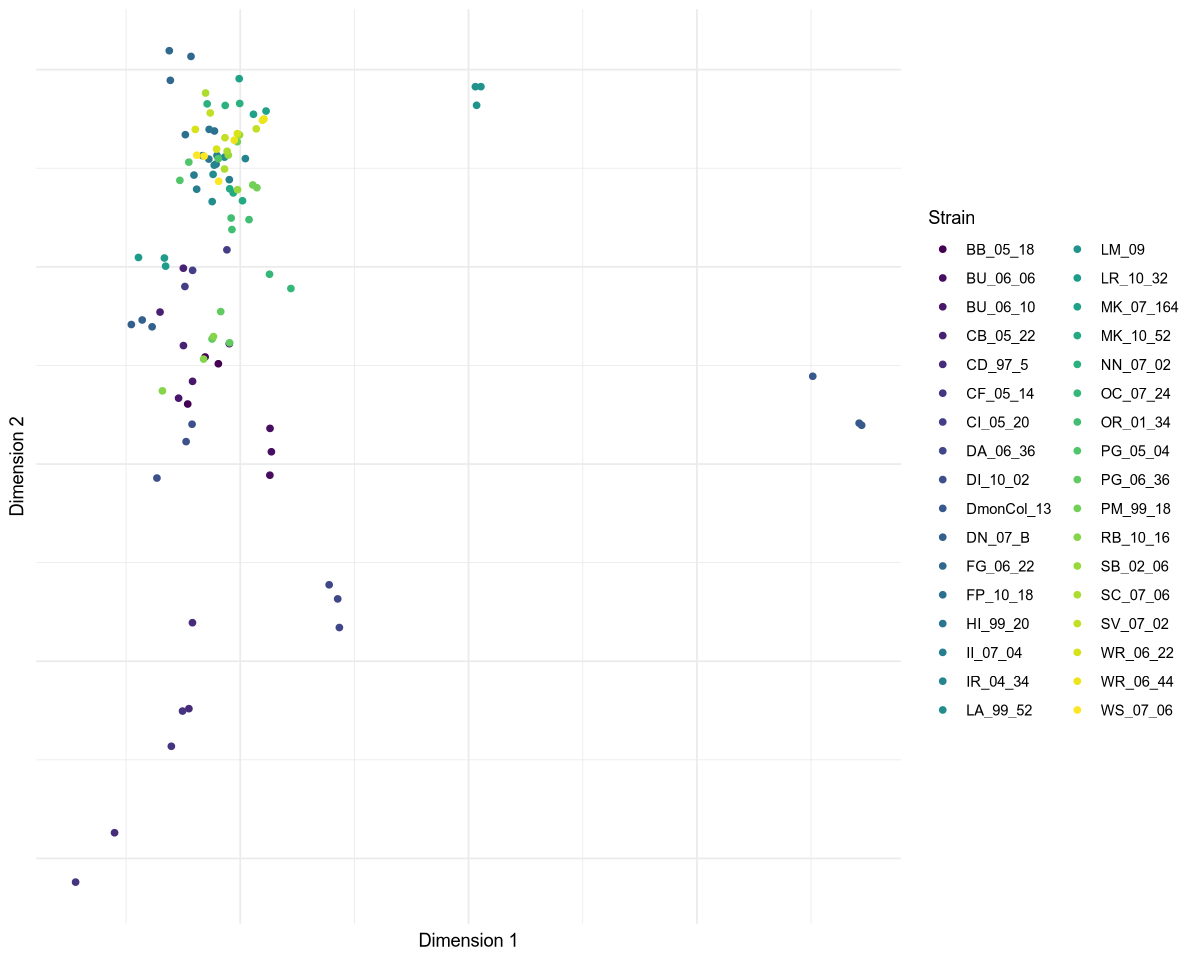

In [ ]:
## increase reads by 1, to account for genes with 0 reads
variance_reads_mx <- variance_filtered_data + 1

## create MDS object
mds_coords <- plotMDS(variance_reads_mx + 1, plot = F)
mdsObj <- data.frame(dim1 = mds_coords$x, dim2 = mds_coords$y)
mdsObj$sample <- sample_info$sample

mdsObj <- merge(mdsObj, sample_info, by.x = "sample")

## plot MDS
options(repr.plot.width = 10, repr.plot.height = 8)
MDS <- mdsObj %>%
    ggplot(aes(x = dim1, y = dim2, color = strain)) +
    geom_point() +
    labs(x = "Dimension 1", y = "Dimension 2", color = "Strain") +
    scale_color_viridis(discrete = TRUE) +
    theme_minimal() +
    theme(axis.text = element_blank())
MDS

In [ ]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_mds.png", MDS)

Saving 7 x 7 in image


Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


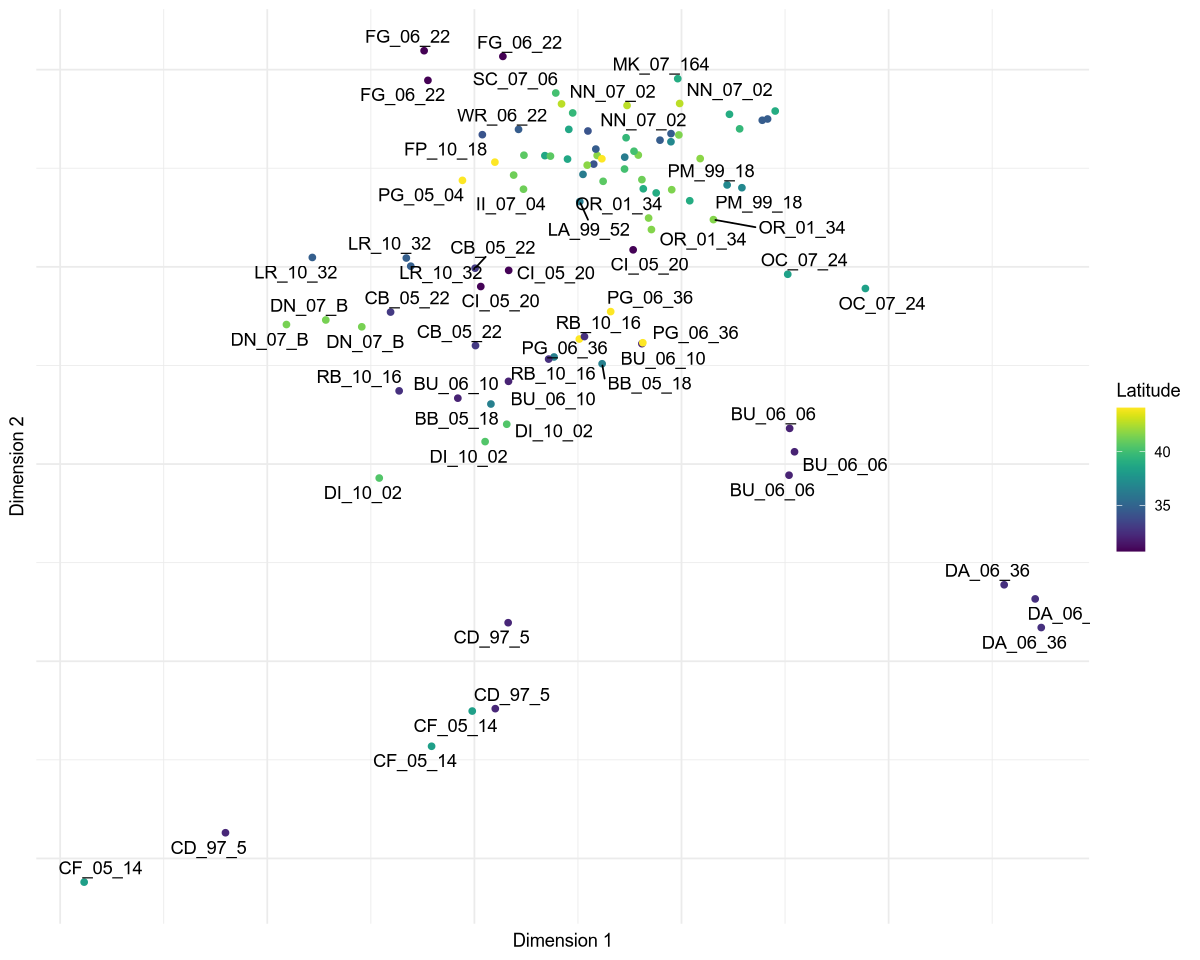

In [ ]:
## plot MDS to see correlation wiht latitude
mds_lat <- mdsObj %>%
    left_join(local_lat, by = "locality") %>%
    na.omit()

mds_lat_plot <- mds_lat %>%
    unique() %>%
    ggplot(aes(x = dim1, y = dim2, label = strain)) +
        geom_point(aes(color = latitude)) +
        geom_text_repel(xlim = c(NA, Inf), ylim = c(-Inf, Inf)) +
        labs(x = "Dimension 1", y = "Dimension 2", color = "Latitude") +
        scale_color_viridis() +
        theme_minimal() +
        theme(axis.text = element_blank())
mds_lat_plot

In [ ]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_mds_lat.png", mds_lat_plot)

Saving 7 x 7 in image


Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [ ]:
# ## create empty dataframe to populate
# mds_obj <- mds_lat %>%
#     pivot_longer(c(dim1, dim2), names_to = "dimension", values_to = "whole_transcriptome")

# ## create mds for each chromosome
# for (i in unique(gtf_genes$chromosome)) {
    
#     ## get the list of genes on the relevent chromosome
#     chr_genes <- gtf_genes %>%
#         filter(chromosome == i) %>%
#         pull("gene") %>%
#         unique()
    
#     ## filter read data for only chromosome genes
#     chr_reads_mx <- variance_reads_mx[rownames(variance_reads_mx) %in% chr_genes, ]
    
#     ## plot chromosome specific MDS
#     mds_coords <- plotMDS(chr_reads_mx + 1, plot = F)
#     mdsObj <- data.frame(dim1 = mds_coords$x, dim2 = mds_coords$y)
#     mdsObj$sample <- sample_info$sample

#     ## add chromosome information to data frame
#     mdsObj <- mdsObj %>%
#         pivot_longer(!sample, names_to = "dimension", values_to = i)
#     mds_obj <- mds_obj %>%
#         full_join(mdsObj, by = c("sample", "dimension"))
# }

# ## remove initial column and transform dimension and chromosome
# mds_obj <- mds_obj %>%
#     select(-whole_transcriptome) %>%
#     pivot_longer(contains("Chr"), names_to = "chromosome", values_to = "values") %>%
#     pivot_wider(names_from = dimension, values_from = values) %>%
#     na.omit()

# write_tsv(mds_obj, "intermediate/chromosome_mds.tsv")

Rows: 570 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): sample, locality, female, number, replicate, strain, chromosome
dbl (3): latitude, dim1, dim2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“ggrepel: 90 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 92 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 82 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 82 unlabeled data points (too many overlaps). Consider increa

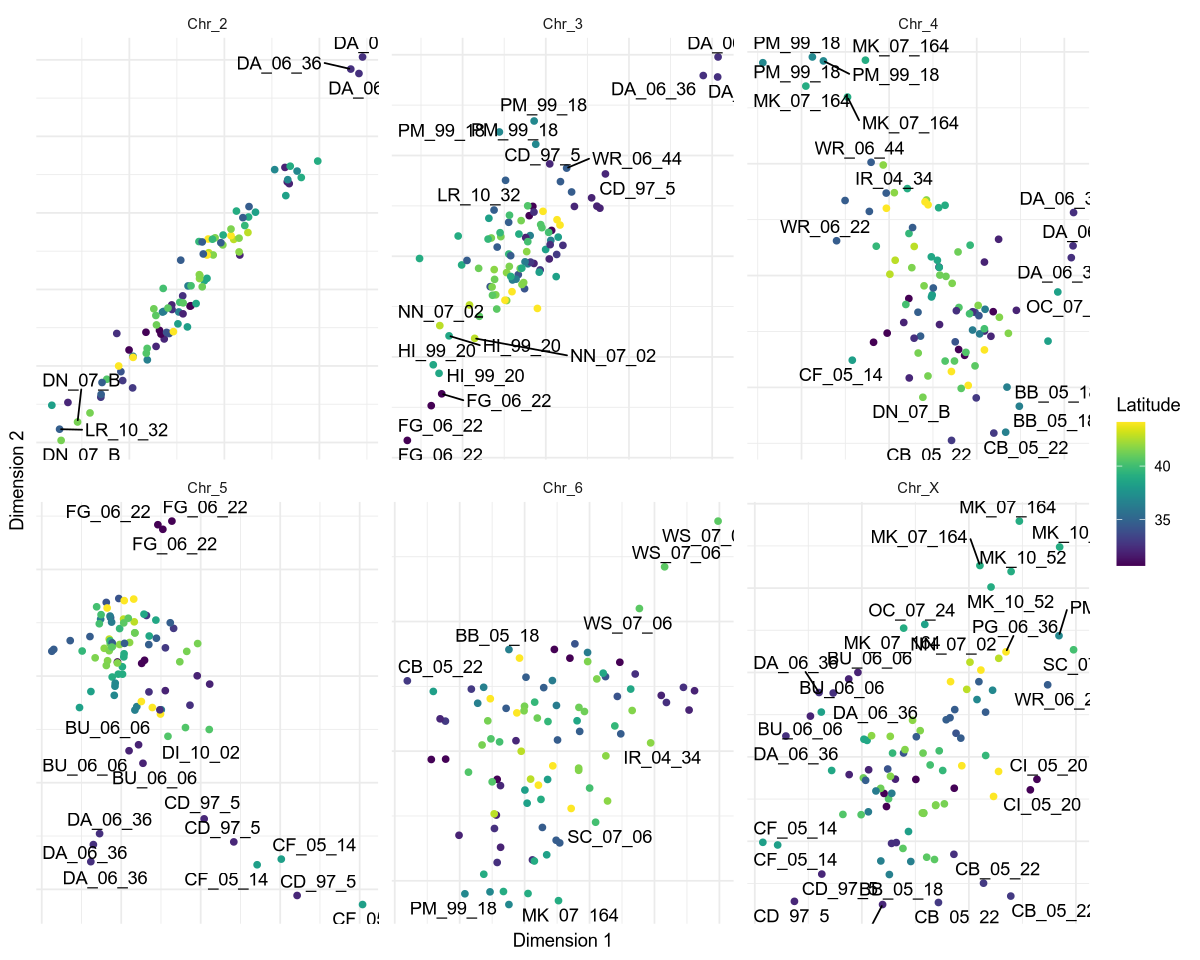

In [ ]:
## load in MDS plot
mds_obj <- read_tsv("intermediate/chromosome_mds.tsv")

## plot MDS by chromosome
mds_chr_plot <- mds_obj %>%
    unique() %>%
    ggplot(aes(x = dim1, y = dim2, label = strain)) +
        geom_point(aes(color = latitude)) +
        geom_text_repel(xlim = c(NA, Inf), ylim = c(-Inf, Inf)) +
        labs(x = "Dimension 1", y = "Dimension 2", color = "Latitude") +
        scale_color_viridis() +
        theme_minimal() +
        theme(axis.text = element_blank(),
              panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome, scales = "free")
mds_chr_plot

In [ ]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_chr_mds_lat+labels.png", mds_chr_plot, width = 10, height = 8)

Warning message:
“ggrepel: 89 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 79 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 78 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 87 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 76 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 70 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [ ]:
## combine the latitude and expression data
chr_expression_lat <- variance_filtered_data %>%
    scale() %>%
    as.data.frame() %>%
    rownames_to_column("gene") %>%
    pivot_longer(!gene, names_to = "sample", values_to = "expression") %>%
    left_join(gtf_genes, by = "gene", relationship = "many-to-many") %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "strain", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    inner_join(local_lat, by = "locality") %>%
    filter(!is.na(chromosome))

# chr_expression_lat_box <- chr_expression_lat %>%
#     mutate(chromosome = str_replace(chromosome, "Chr_", "Chromosome ")) %>%
#     ggplot(aes(x = fct_reorder(locality, latitude), y = log2(expression), color = latitude)) +
#         geom_boxplot(outlier.shape = NA) +
#         labs(x = "Locality", y = "log2(Normalized Gene Expression)", color = "Latitude") +
#         scale_color_viridis() +
#         theme_minimal() +
#         theme(panel.background = element_rect(fill = "white", color = NA),
#               plot.background = element_rect(fill = "white", color = NA),
#               legend.position = "top") +
#         facet_grid(rows = vars(chromosome), scales = "free_x")
# chr_expression_lat_box

### Determine if there is a difference in expression based on fusion status

#### LogFC for fusion status alone

In [ ]:
## create a sample info dataframe with fusion status
sample_info <- colnames(normalized_reads) %>%
    as.data.frame() %>%
    rename(sample = 1) %>%
    filter(grepl("_", sample)) %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate),
           number = case_when(replicate == number ~ NA,
                              TRUE ~ number),
           strain = case_when(is.na(number) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_"))) %>%
    left_join(local_lat, by = "locality") %>%
    left_join(fusion, by = "strain") %>%
    select(sample, strain, status, latitude, locality)
head(sample_info)

sample,strain,status,latitude,locality
<chr>,<chr>,<chr>,<dbl>,<chr>
BB_05_18_rep1,BB_05_18,Fused,36.46119,BB
BB_05_18_rep2,BB_05_18,Fused,36.46119,BB
BB_05_18_rep3,BB_05_18,Fused,36.46119,BB
BU_06_06_rep1,BU_06_06,NA,31.99426,BU
BU_06_06_rep2,BU_06_06,NA,31.99426,BU
BU_06_06_rep3,BU_06_06,NA,31.99426,BU


In [ ]:
## calculate logfc based on fusion status

## create empty logfc table to add the future log fold change data to
logfc_fusion <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality != "SB")
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_latitude <- trunc_sample_info$latitude
trunc_design <- model.matrix(~ trunc_groups + trunc_latitude)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_fusion <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fusion, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.ob

In [ ]:
## count how many significant and unsignificant genes
logfc_fusion %>%
    group_by(significance) %>%
    count()
## excluding SB increased the significant genes from 91 to 157

significance,n
<chr>,<int>
Not Significant,10468
Significant,157


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


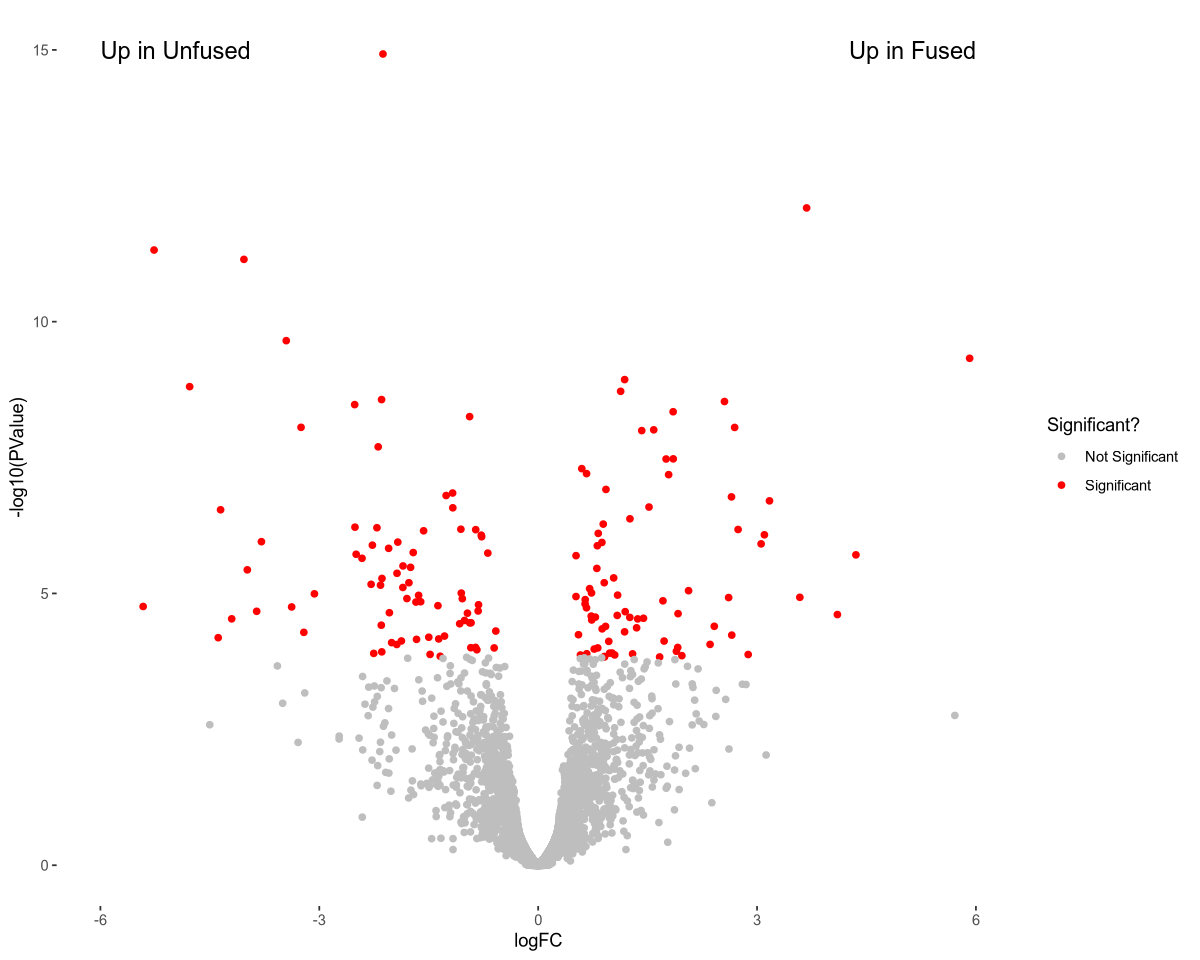

In [ ]:
## plot volcano for fusion
fusion_volcano <- logfc_fusion %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        annotate("text", x = 6, y = 15, hjust = 1,
             size = 5, label = "Up in Fused") +
        annotate("text", x = -6, y = 15, hjust = 0,
             size = 5, label = "Up in Unfused")
fusion_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/fusion_volcano.png", fusion_volcano)

Saving 7 x 7 in image


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [ ]:
## add location information to logfc data
logfc_fusion_chr <- gtf_genes %>%
    full_join(logfc_fusion, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_fusion_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fusion_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fusion_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(is.numeric, replace_na, replace = 0)`.
ℹ In group 1: `fourth = "fourth"`.
Caused by warning:
! Use of bare predicate functions was deprecated in tidyselect 1.1.0.
ℹ Please use wrap predicates in `where()` instead.
  # Was:
  data %>% select(is.numeric)

  # Now:
  data %>% select(where(is.numeric))
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


[1] 0.3146108

[1] 0.3943453

[1] 0.01047379

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


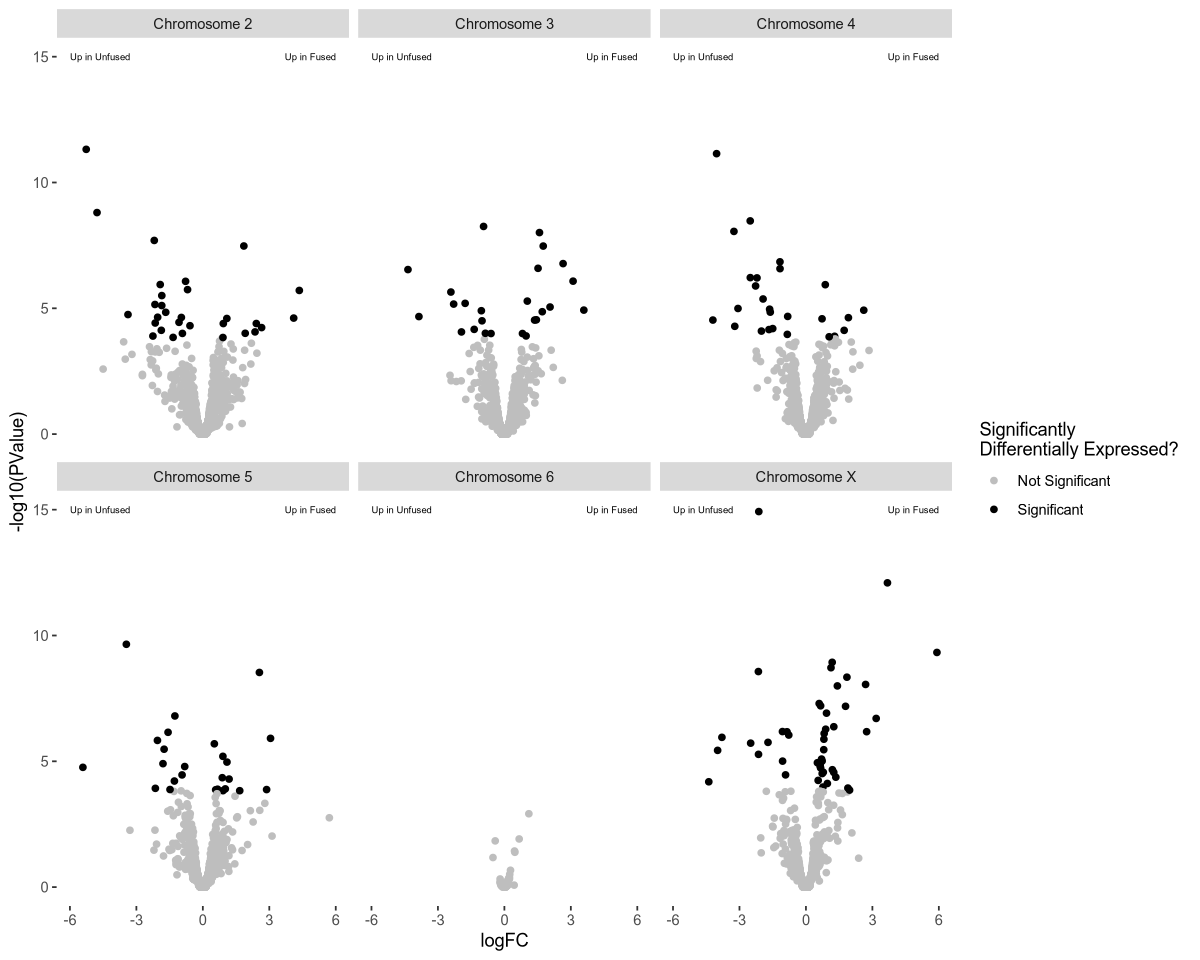

In [ ]:
## plot volcano for fusion
fusion_chr_volcano <- logfc_fusion_chr %>%
    mutate(chromosome = str_replace_all(chromosome, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly\nDifferentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        annotate("text", x = 6, y = 15, hjust = 1,
             size = 2, label = "Up in Fused") +
        annotate("text", x = -6, y = 15, hjust = 0,
             size = 2, label = "Up in Unfused") +
        facet_wrap(~chromosome)
fusion_chr_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/fusion_chr_volcano.png", fusion_chr_volcano, width = 12, height = 7)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


#### Determine if there is a difference in expression based on fusion status and fixation of fusion

In [ ]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "CI", "RB")
fixed_test <- sample_info %>% 
    # filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
fixed_test

sample,strain,status,latitude,locality
<chr>,<chr>,<chr>,<dbl>,<chr>
CI_05_20_rep1,CI_05_20,NA,30.75824,CI
CI_05_20_rep2,CI_05_20,NA,30.75824,CI
CI_05_20_rep3,CI_05_20,NA,30.75824,CI
PG_05_04_rep1,PG_05_04,Fused,44.09362,PG
PG_05_04_rep2,PG_05_04,Fused,44.09362,PG
PG_05_04_rep3,PG_05_04,Fused,44.09362,PG
PG_06_36_rep1,PG_06_36,NA,44.09362,PG
PG_06_36_rep2,PG_06_36,NA,44.09362,PG
PG_06_36_rep3,PG_06_36,NA,44.09362,PG


#### Try to increase signal by only including localities with close to fix rates that match fusion status

In [ ]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "IR", "DI", "HI", "CF", "CI", "RB", "CB", "FP")

## determine which fixed localities have the corresponding fusion status in our strains
fixed_test <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
## PG, HI, and IR in the north and RB and FP in the south

## filter for properly fixed locations
fixed <- c("PG", "IR", "HI", "RB", "FP")
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed)

In [ ]:
# ## calculate logfc based on fusion status for populations

## create empty logfc table to add the future log fold change data to
logfc_fixed <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_design <- model.matrix(~ trunc_groups)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_nearfixed <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fixed, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.ob

In [ ]:
## count how many significant and unsignificant genes
logfc_nearfixed %>%
    group_by(significance) %>%
    count()

significance,n
<chr>,<int>
Not Significant,10568
Significant,57


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


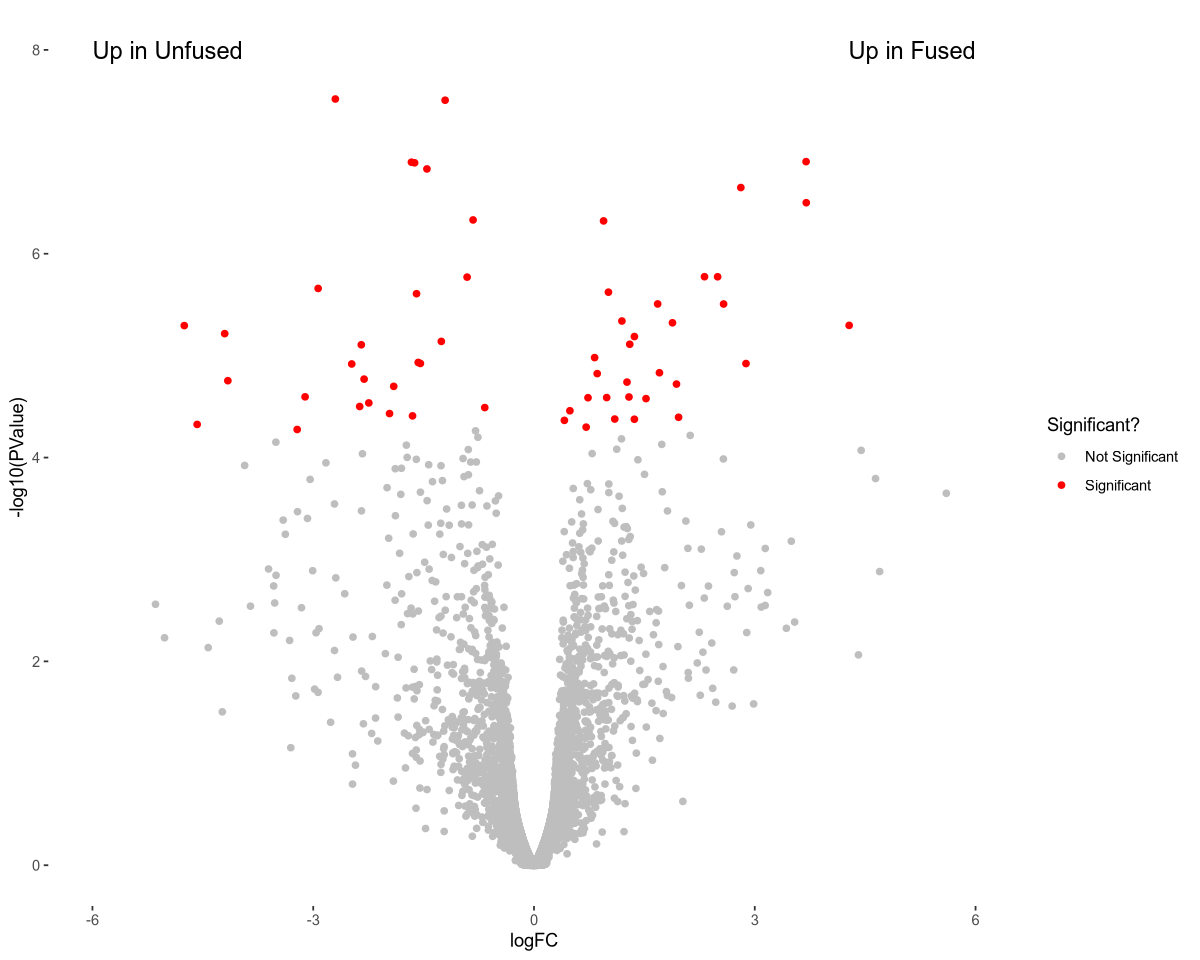

In [ ]:
## plot volcano for fusion
nearfixed_volcano <- logfc_nearfixed %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        annotate("text", x = 6, y = 8, hjust = 1,
             size = 5, label = "Up in Fused") +
        annotate("text", x = -6, y = 8, hjust = 0,
             size = 5, label = "Up in Unfused")
nearfixed_volcano

In [ ]:
## add location information to logfc data
logfc_nearfixed_chr <- gtf_genes %>%
    full_join(logfc_nearfixed, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_nearfixed_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

[1] 0.06322192

[1] 0.01994659

[1] 1

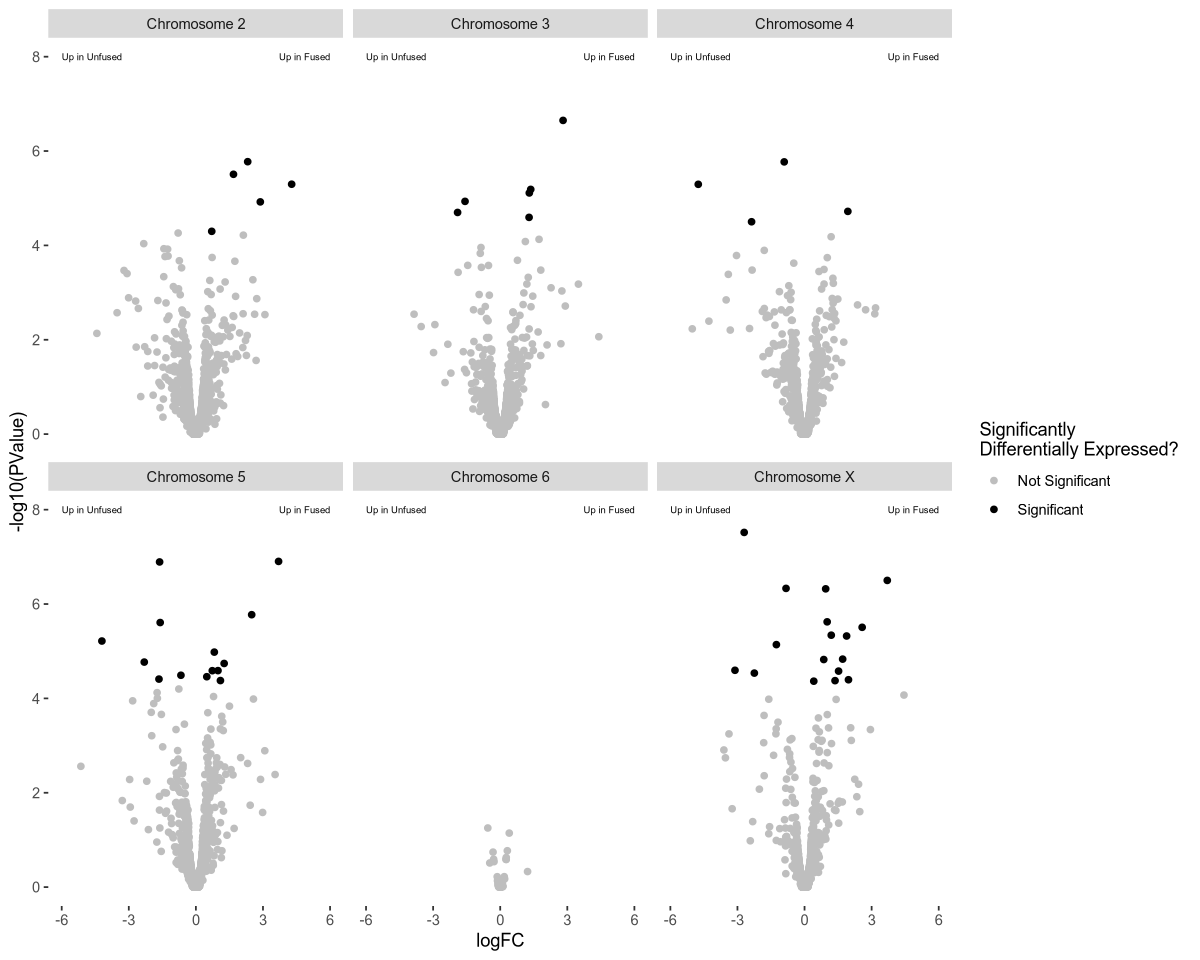

In [ ]:
## plot volcano for fusion
nearfixed_chr_volcano <- logfc_nearfixed_chr %>%
    mutate(chromosome = str_replace_all(chromosome, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly\nDifferentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        annotate("text", x = 6, y = 8, hjust = 1,
             size = 2, label = "Up in Fused") +
        annotate("text", x = -6, y = 8, hjust = 0,
             size = 2, label = "Up in Unfused") +
        facet_wrap(~chromosome)
nearfixed_chr_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/nearfixed_chr_volcano.png", nearfixed_chr_volcano, width = 12, height = 7)

### Find genes whose expression correlated with latitude

In [ ]:
# ## get the list of genes to iterate through
# genes <- unique(lat_expression$gene)

# ## create empty data frame to populate
# lmm_df <- matrix(data = NA, nrow = length(genes), ncol = 3,
#                  dimnames = list(genes, c("estimate", "pvalue", "std_err"))) %>%
#   as.data.frame()
  
# ## populate data with correlation information
# for (i in genes) {
  
#   ## filter data frame for only gene of interest
#   lat_expression_gene <- lat_expression %>%
#     filter(gene == i)
  
#   ## calculate correlation between gene expression and latitude and save output
#   lmm_result <- summary(lmer(count ~ latitude + (1| locality / strain), data = lat_expression_gene))
#   estimate <- lmm_result$coefficients["latitude","Estimate"]
#   pvalue <- lmm_result$coefficients["latitude","Pr(>|t|)"]
#   std_err <- lmm_result$coefficients["latitude","Std. Error"]
  
#   ## store output in data frame
#   lmm_df[[i, "estimate"]] <- estimate
#   lmm_df[[i, "pvalue"]] <- pvalue
#   lmm_df[[i, "std_err"]] <- std_err
  
# }

# ## add rownames as a column
# lmm_df <- lmm_df %>%
#   rownames_to_column("gene")

# ## correct pvalue for false discovery rate
# lmm_df$pvalue_corrected <- p.adjust(lmm_df$pvalue, method = "BH")

# write_tsv(lmm_df, "lat-ge_lmm.tsv")

In [ ]:
## load in correlation data frame
lmm_df <- read_tsv("intermediate/lat-ge_lmm.tsv")
head(lmm_df)

Rows: 10625 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): gene
dbl (4): estimate, pvalue, std_err, pvalue_corrected

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


gene,estimate,pvalue,std_err,pvalue_corrected
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,-106.3728403,0.08178567,59.067602,0.4510192
mRpL55,0.3468941,0.88058541,2.283499,0.9648740
ATPsynD,5.3204653,0.77717534,18.598461,0.9259074
sav,3.0304692,0.64915932,6.581749,0.8781921
Ctns,2.5131739,0.74916087,7.787954,0.9143206
p53,-2.0768906,0.21432128,1.637068,0.6074421


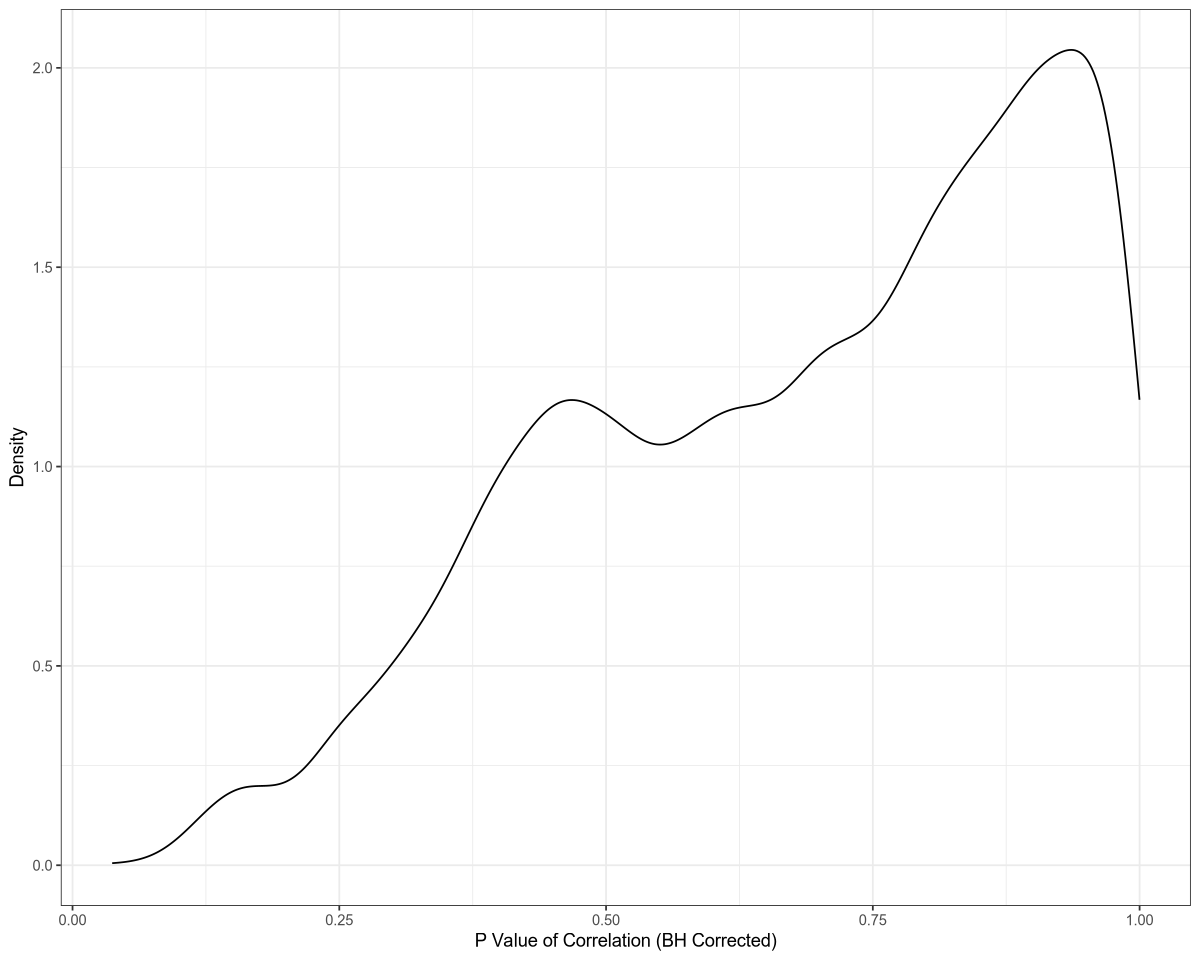

In [ ]:
## plot the density of genes with significant correlations to latitude
lmm_density <- lmm_df %>%
    ggplot(aes(x = pvalue_corrected)) +
        geom_density() +
        labs(x = "P Value of Correlation (BH Corrected)", y = "Density") +
        theme_bw()
lmm_density

Warning message:
“Removed 10623 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


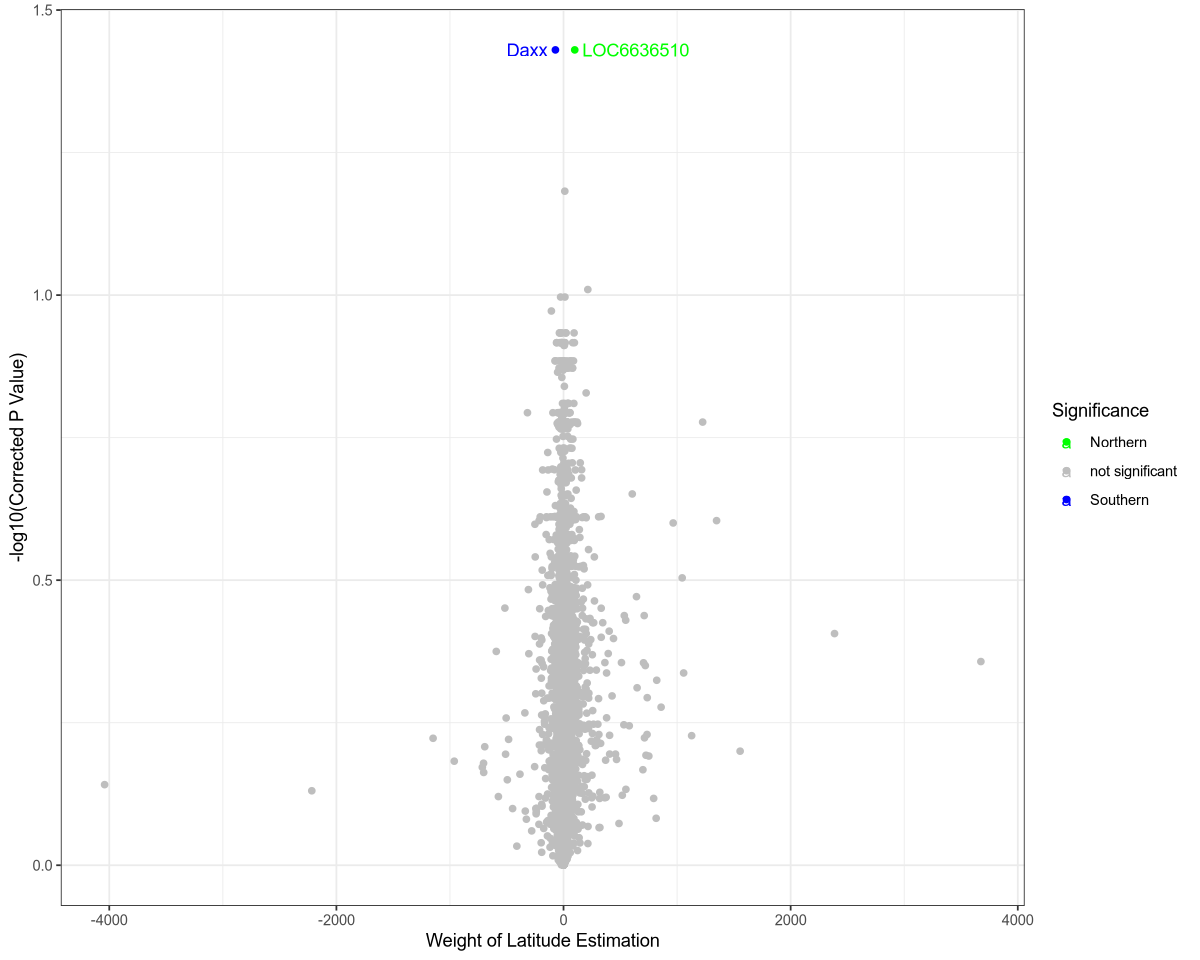

In [ ]:
## annotate genes based on their correlations
lmm_genes_annotated <- lmm_df %>%
    mutate(significance = case_when(pvalue_corrected < 0.05 ~ "Significant",
                                    TRUE ~ "Not Significant"),
           lat_cor = case_when(pvalue_corrected < 0.05 & estimate > 0 ~ "Northern",
                               pvalue_corrected < 0.05 & estimate < 0 ~ "Southern",
                               TRUE ~ "not significant"),
           label = case_when(pvalue_corrected < 0.05 ~ gene,
                             TRUE ~ NA))

## make a pseudo volcano plot
lmm_genes_volcano <- lmm_genes_annotated %>%
    ggplot(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_point(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_text_repel(aes(label = label)) +
        labs(x = "Weight of Latitude Estimation", y = "-log10(Corrected P Value)",
             color = "Significance") +
        scale_color_manual(values = c("Green", "Gray", "Blue")) +
        theme_bw()
lmm_genes_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/sb_reads_lmm_lat.png", lmm_genes_volcano)

Saving 7 x 7 in image


Warning message:
“Removed 10623 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


In [ ]:
gtf_genes %>%
    filter(gene == "Daxx" | grepl("LOC663651", gene))

chromosome,gene
<chr>,<chr>
Chr_4,Daxx
Chr_5,LOC6636512
Chr_5,LOC6636511


## Identify SNPs that correlate with gene expression

### Load in data

In [ ]:
# # load in EQTLs
# cis <- read_csv("../workflow/eqtl/tensorqtl/results/vg_pruned.cis_qtl_pairs.txt.gz") %>%
#     filter(pval_nominal < 0.05) %>%
#     mutate(relationship = "cis")
# trans <- read_tsv("../workflow/eqtl/tensorqtl/results/vg_pruned.trans_qtl_pairs.txt.gz") %>%
#     mutate(relationship = "trans")

# ## reformat the data frames to combine them
# trans <- trans %>%
#     select(variant_id, phenotype_id, af, pval, relationship)
# cis <- cis %>%
#     rename(pval = pval_nominal) %>%
#     select(variant_id, phenotype_id, af, pval, relationship)

# ## combine the two dataframes
# eqtl <- rbind(trans, cis)

# ## save eQTL combined information
# write_tsv(eqtl, "intermediate/eqtl_ld.tsv")

In [ ]:
## load in eQTL data
eqtl <- read_tsv("intermediate/eqtl_ld.tsv")
head(eqtl)

Rows: 7961411 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): variant_id, phenotype_id, relationship
dbl (2): af, pval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


variant_id,phenotype_id,af,pval,relationship
<chr>,<chr>,<dbl>,<dbl>,<chr>
>5884>5887,LOC6623677,0.0714286,4.96055e-07,trans
>5884>5887,DIP-kappa,0.0714286,2.13454e-07,trans
>6495>6498,Dscam3,0.0357143,6.93826e-07,trans
>6495>6498,TwdlT,0.0357143,5.59207e-07,trans
>6495>6498,LOC6632814,0.0357143,3.29504e-13,trans
>6495>6498,slo,0.0357143,9.00777e-06,trans


In [ ]:
# ## load in SNP information
# snps <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated_snps.vcf", skip = 513) %>%
#     janitor::clean_names() %>%
#     filter(grepl("Chr_", number_chrom))

# ## add EQTL location information
# eqtl_loc <- snps %>%
#     select(number_chrom, pos, id) %>%
#     unique() %>%
#     rename(variant_id = id) %>%
#     right_join(eqtl, by = "variant_id")
# eqtl_loc <- gtf %>%
#     select(gene, chromosome, start) %>%
#     rename(phenotype_id = gene, phenotype_start = start) %>%
#     right_join(eqtl_loc, by = "phenotype_id", relationship = "many-to-many")

# write_tsv(eqtl_loc, "intermediate/eqtl_loc.tsv")

In [ ]:
## load in eQTL location dataframe
eqtl_loc <- read_tsv("intermediate/eqtl_loc.tsv")
head(eqtl_loc)

Rows: 15521012 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): phenotype_id, chromosome, number_chrom, variant_id, relationship
dbl (4): phenotype_start, pos, af, pval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


phenotype_id,chromosome,phenotype_start,number_chrom,pos,variant_id,af,pval,relationship
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
ATPsynD,Chr_2,113108,Chr_2,172880,>5769>5772,0.42857143,0.005984385,cis
ATPsynD,Chr_2,113108,Chr_2,179596,>6080>6083,0.17857142,0.037240392,cis
ATPsynD,Chr_2,113108,Chr_2,190165,>6552>6555,0.25000000,0.007333591,cis
ATPsynD,Chr_2,113108,Chr_2,191129,>6585>6588,0.46428573,0.031508287,cis
ATPsynD,Chr_2,113108,Chr_2,225105,>8120>8123,0.10714286,0.027575061,cis
ATPsynD,Chr_2,113108,Chr_2,234792,>8552>8555,0.07142857,0.018780388,cis


### Plot the location of eQTLS relative to the regulated gene

In [ ]:
## plot the relative location of each eQTL and the effected gene
eqtl_loc_graph <- eqtl_loc %>%
    na.omit() %>%
    ggplot(aes(x = pos, y = phenotype_start, color = -log10(pval)), size = 0.001) +
        geom_point() +
        labs(x = "eQTL position", y = "Target Gene Position", color = "-log10(FDR)") +
        scale_color_viridis() +
        # scale_x_continuous(expand = c(0, 0)) +
        # scale_y_continuous(expand = c(0, 0), limits = c(0, NA)) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_grid(cols = vars(number_chrom), rows = vars(chromosome),
                   scales = "free", switch = "x")
eqtl_loc_graph

In [ ]:
## save plot
ggsave("figures/eqtl_fusion/tensorqtl_eqtl_location.png", eqtl_loc_graph, width = 12, height = 12)

### Determine if the eQTLs are enriched for specific predicted functions

In [ ]:
# ## load in SNP information
# snpeff <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated.snpeff.vcf", skip = 516) %>%
#     janitor::clean_names()
# snpeff <- snpeff[ , 1:8] %>%
#     filter(grepl("Chr_", number_chrom)) %>%
#     separate_wider_delim(info, delim = "|", too_many = "merge", too_few = "align_start",
#                          names = c("info", "annotation", "annotation_impact", "gene_name", "gene_id", 
#                                    "feature_type", "feature_id", "transcript_biotype", "rank", "HGVS.c", 
#                                    "HGVS.p", "cDNA.pos_cDNA.length", "CDS.pos_CDS.length", "AA.pos_AA.length", 
#                                    "Distance", "ERRORS_WARNINGS_INFO", "snpeff_extra")) %>%
#     select(number_chrom, pos, id, annotation, annotation_impact) %>%
#     unique() %>%
#     separate_longer_delim(annotation, delim = "&") %>%
#     rename(variant_id = id) %>%
#     select(variant_id, annotation) %>%
#     full_join(eqtl_loc, by = "variant_id")

# write_tsv(snpeff, "intermediate/vg_annotated.snpeff.effect.tsv")

In [ ]:
## load in SnpEff results
snpeff <- read_tsv("intermediate/vg_annotated.snpeff.effect.tsv")
head(snpeff)

In [78]:
# ## load in full SNP data frame
# snps <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated_snps.vcf", skip = 513) %>%
#     janitor::clean_names() %>%
#     filter(grepl("Chr_", number_chrom))

# ## determine if there is an enrichment of specific predicted effects in the eQTLs
# effects <- na.omit(unique(snpeff$annotation))

# ### create empty data frame to populate
# eqtl_effects <- matrix(NA, nrow = length(effects), ncol = 3,
#                    dimnames = list(effects, c("pvalue", "number_eqtl", "number_noneqtl"))) %>%
#     as.data.frame()

# ### calculate enrichment
# for (i in effects) {

#     ## get list of SNPs with specific effect
#     effect_snps <- snpeff %>%
#         filter(annotation == i) %>%
#         pull(variant_id) %>%
#         unique()

#     ## count number of SNPs with effect
#     effect_matrix <- snps %>%
#         mutate(eqtl = case_when(id %in% eqtl$variant_id ~ "no_eqtl",
#                                 TRUE ~ "eqtl"),
#                effect = case_when(id %in% effect_snps ~ "effect",
#                                   TRUE ~ "no_effect")) %>%
#         select(id, eqtl, effect) %>%
#         unique() %>%
#         group_by(eqtl, effect) %>%
#         count() %>%
#         pivot_wider(names_from = effect, values_from = n) %>%
#         column_to_rownames("eqtl") %>%
#         mutate_all(~replace_na(., 0)) %>%
#         as.matrix()

#     ## only populate if there is the proper format of the data frame
#     if (ncol(effect_matrix) == 2 & nrow(effect_matrix) == 2) {    

#     ## save the number of SNPs that are eQTLs and not eQTLs with annotation as a variable
#     number_eqtl <- effect_matrix["eqtl", "effect"]
#     number_noneqtl <- effect_matrix["no_eqtl", "effect"]

#         ## ensure that the number of eQTLs is high enough to warrant a chi squared
#         if (number_eqtl > 5 & number_noneqtl > 5) {

#             ## calculate enrichment of effect with chi squared
#             effect_chisq <- effect_matrix %>%
#                 chisq.test()
            
#             ## populate data frame with results
#             eqtl_effects[[i, "pvalue"]] <- effect_chisq$p.value

#         } else {

#             ## calculate enrichment of effect with fisher exact test
#             effect_fisher <- effect_matrix %>%
#                 fisher.test()
            
#             ## populate data frame with results
#             eqtl_effects[[i, "pvalue"]] <- effect_fisher$p.value

#         }

#         ## add the variable to the data frame
#         eqtl_effects[[i, "number_eqtl"]] <- effect_matrix["eqtl", "effect"]
#         eqtl_effects[[i, "number_noneqtl"]] <- effect_matrix["no_eqtl", "effect"]
#     }
# }

# ### get the number of SNPs that are eQTLs and are not eQTLs
# eqtl_list <- unique(eqtl$variant_id)
# eqtl_number <- length(eqtl_list)
# noneqtl_number <- snpeff$variant_id[!(snpeff$variant_id %in% eqtl_list)] %>%
#     unique() %>% length()

# ### save annotations as column and get ratio of SNPs with annotation
# eqtl_effects <- eqtl_effects %>%
#     rownames_to_column("annotation") %>%
#     mutate(ratio_eqtl = number_eqtl/eqtl_number,
#            ratio_noneqtl = number_noneqtl/noneqtl_number)

# ### perform multiple testing correction
# eqtl_effects$pvalue_corrected <- p.adjust(eqtl_effects$pvalue, method = "BH")

# ### save data frame to tsv
# write_tsv(eqtl_effects, "intermediate/eqtl_effect_enrichment.tsv")

In [79]:
## load in eQTL enrichment data frame
eqtl_effects <- read_tsv("intermediate/eqtl_effect_enrichment.tsv")
head(eqtl_effects)

Rows: 32 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): annotation
dbl (6): pvalue, number_eqtl, number_noneqtl, ratio_eqtl, ratio_noneqtl, pva...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


annotation,pvalue,number_eqtl,number_noneqtl,ratio_eqtl,ratio_noneqtl,pvalue_corrected
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intergenic_region,1.366221e-49,317956,146775,0.33016724,0.049079158,3.552174e-48
downstream_gene_variant,1.126713e-01,240309,116407,0.24953817,0.038924595,2.663141e-01
3_prime_UTR_variant,1.362706e-01,49517,24137,0.05141872,0.008071018,2.725412e-01
synonymous_variant,1.422942e-37,89003,46078,0.09242120,0.015407729,1.849825e-36
intron_variant,4.292659e-02,650531,312319,0.67551492,0.104434362,1.240102e-01
missense_variant,4.247860e-14,53756,27375,0.05582052,0.009153752,3.681479e-13


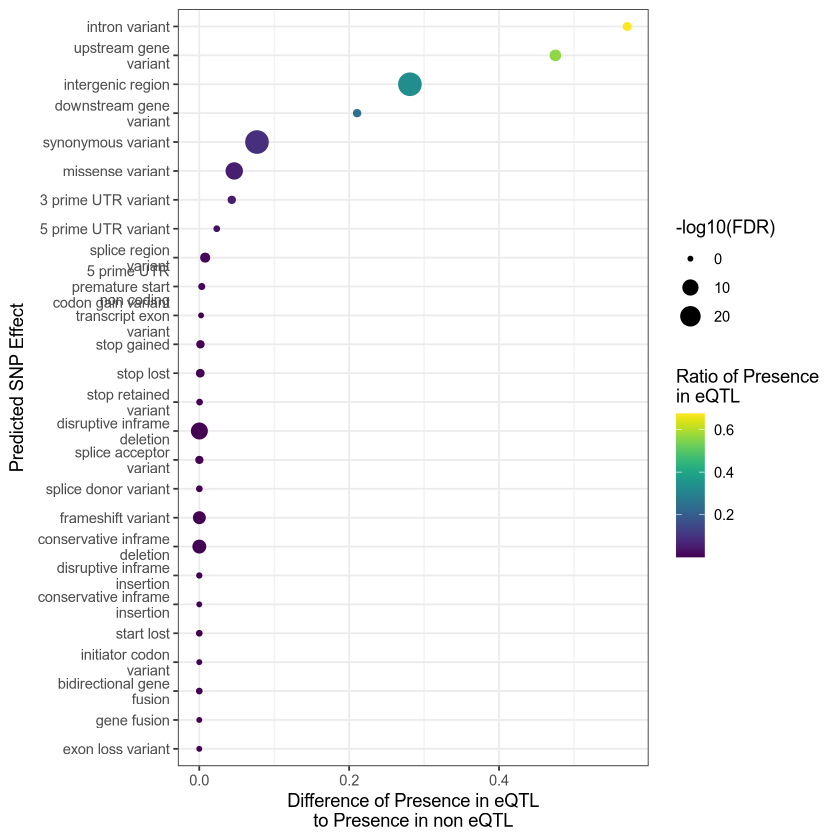

In [80]:
## look at the enrichment of 
eqtl_effect_dot <- eqtl_effects %>%
    mutate(pvalue_corrected = case_when(pvalue_corrected < 2.15e-30 ~  2.15e-30,
                                        TRUE ~ pvalue_corrected),
           annotation = str_replace_all(annotation, "_", " "),
           annotation = str_wrap(annotation, width = 20),
           direction = ratio_eqtl-ratio_noneqtl) %>%
    na.omit() %>%
    ggplot(aes(x = fct_reorder(annotation, direction), y = direction, color = ratio_eqtl, size = -log10(pvalue_corrected))) +
        geom_point() +
        labs(x = "Predicted SNP Effect", y = "Difference of Presence in eQTL\nto Presence in non eQTL",
             color = "Ratio of Presence\nin eQTL", size = "-log10(FDR)") +
        scale_color_viridis() +
        theme_bw() +
        coord_flip()
eqtl_effect_dot

In [81]:
## save plot
ggsave("figures/eqtl_fusion/tensorqtl_eqtl_effect.png", eqtl_effect_dot, width = 12, height = 7)

In [86]:
## load in full SNP data frame
snps <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated_snps.vcf", skip = 513) %>%
    janitor::clean_names() %>%
    filter(grepl("Chr_", number_chrom))

## determine if there is an enrichment of specific predicted effects in the eQTLs
effects <- na.omit(unique(snpeff$annotation))
chromosomes <- na.omit(unique(snpeff$number_chrom))

### create empty data frame to populate
eqtl_effects <- matrix(NA, nrow = length(effects), ncol = 4,
                   dimnames = list(effects, c("chromosome", "pvalue", "number_eqtl", "number_noneqtl"))) %>%
    as.data.frame()

### calculate enrichment
for (j in chromosomes) {
    for (i in effects) {

        ## get list of SNPs with specific effect
        effect_snps <- snpeff %>%
            filter(annotation == i) %>%
            pull(variant_id) %>%
            unique()

        ## count number of SNPs with effect
        effect_matrix <- snpeff %>%
            filter(number_chrom == j) %>%
            mutate(eqtl = case_when(variant_id %in% eqtl$variant_id ~ "no_eqtl",
                                    TRUE ~ "eqtl"),
                effect = case_when(variant_id %in% effect_snps ~ "effect",
                                    TRUE ~ "no_effect")) %>%
            select(variant_id, eqtl, effect) %>%
            unique() %>%
            group_by(eqtl, effect) %>%
            count() %>%
            pivot_wider(names_from = effect, values_from = n) %>%
            column_to_rownames("eqtl") %>%
            mutate_all(~replace_na(., 0)) %>%
            as.matrix()

    ## only populate if there is the proper format of the data frame
    if (ncol(effect_matrix) == 2 & nrow(effect_matrix) == 2) {    

        ## save the number of SNPs that are eQTLs and not eQTLs with annotation as a variable
        number_eqtl <- effect_matrix["eqtl", "effect"]
        number_noneqtl <- effect_matrix["no_eqtl", "effect"]

        ## ensure that the number of eQTLs is high enough to warrant a chi squared
        if (number_eqtl > 5 & number_noneqtl > 5) {

            ## calculate enrichment of effect with chi squared
            effect_chisq <- effect_matrix %>%
                chisq.test()
            
            ## populate data frame with results
            eqtl_effects[[i, "pvalue"]] <- effect_chisq$p.value

        } else {

            ## calculate enrichment of effect with fisher exact test
            effect_fisher <- effect_matrix %>%
                fisher.test()
            
            ## populate data frame with results
            eqtl_effects[[i, "pvalue"]] <- effect_fisher$p.value

        }

            ## add the variable to the data frame
            eqtl_effects[[i, "chromosome"]] <- j
            eqtl_effects[[i, "number_eqtl"]] <- effect_matrix["eqtl", "effect"]
            eqtl_effects[[i, "number_noneqtl"]] <- effect_matrix["no_eqtl", "effect"]
            
        }
    }
}

### get the number of SNPs that are eQTLs and are not eQTLs
eqtl_list <- unique(eqtl$variant_id)
eqtl_number <- length(eqtl_list)
noneqtl_number <- snpeff$variant_id[!(snpeff$variant_id %in% eqtl_list)] %>%
    unique() %>% length()

### save annotations as column and get ratio of SNPs with annotation
eqtl_effects <- eqtl_effects %>%
    rownames_to_column("annotation") %>%
    mutate(ratio_eqtl = number_eqtl/eqtl_number,
           ratio_noneqtl = number_noneqtl/noneqtl_number)

### perform multiple testing correction
eqtl_effects$pvalue_corrected <- p.adjust(eqtl_effects$pvalue, method = "BH")

### save data frame to tsv
write_tsv(eqtl_effects, "intermediate/eqtl_effect_enrichment_chr.tsv")

In [ ]:
## load in eQTL enrichment by chromosome data frame
eqtl_chr <- read_tsv("intermediate/eqtl_effect_enrichment_chr.tsv")
head(eqtl_chr)

Rows: 32 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): annotation
lgl (7): chromosome, pvalue, number_eqtl, number_noneqtl, ratio_eqtl, ratio_...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


annotation,chromosome,pvalue,number_eqtl,number_noneqtl,ratio_eqtl,ratio_noneqtl,pvalue_corrected
<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
intergenic_region,NA,NA,NA,NA,NA,NA,NA
downstream_gene_variant,NA,NA,NA,NA,NA,NA,NA
3_prime_UTR_variant,NA,NA,NA,NA,NA,NA,NA
synonymous_variant,NA,NA,NA,NA,NA,NA,NA
intron_variant,NA,NA,NA,NA,NA,NA,NA
missense_variant,NA,NA,NA,NA,NA,NA,NA
